In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt


In [20]:
!pip install pyts -q
!pip install h5py scikit-learn matplotlib seaborn torch torchvision scipy -q

# 📡 RadioML 2018.01A 多模态频谱感知教学讲义
## —— 双分支 BiLSTM + 8模态 ResNet18 + 双向交叉注意力融合

---

**教学目标**

本讲义将带领学生从零开始，完整实现一个面向**开放集频谱感知**的深度学习系统，涵盖：

1. RadioML 2018.01A 数据集的加载与理解
2. 分层采样策略与 H0/H1 二分类任务构建
3. IQ 原始信号 → **8种时序图像模态**的转换原理与实现
4. 双分支神经网络架构设计（BiLSTM + ResNet18）
5. **双向交叉注意力（Bidirectional Cross-Attention）** 特征融合
6. 完整的三阶段评估体系（验证集、SNR泛化、调制泛化）
7. 科研级可视化（混淆矩阵、ROC、Pd-SNR曲线、**调制×SNR热力图**）

> **任务定义**：频谱感知是认知无线电的核心任务，判断当前信道是否存在主用户信号。
> - **H₁（Hypothesis 1）**：信道被占用，存在主用户信号
> - **H₀（Hypothesis 0）**：信道空闲，仅有背景噪声

---
## Cell 0｜安装与导入依赖

### 📖 所需库说明

| 库 | 版本要求 | 用途 |
|---|---|---|
| `h5py` | ≥3.0 | 读取 RadioML HDF5 格式大文件 |
| `pyts` | ≥0.12 | 时序图像转换（GAF、MTF、RP） |
| `torch` + `torchvision` | ≥1.12 | 深度学习训练，含预训练 ResNet18 |
| `scipy` | ≥1.7 | STFT、Welch 功率谱估计 |
| `sklearn` | ≥1.0 | 评估指标（F1、AUC、ROC等） |
| `seaborn` | ≥0.11 | 热力图等科研可视化 |

### 🔧 随机种子的重要性

固定随机种子保证实验的**可复现性**，是发表论文的必要条件：

$$\text{SEED} = 42 \xrightarrow{\text{固定}} \text{NumPy RNG} + \text{PyTorch RNG} + \text{CUDA RNG}$$

每次运行得到相同的数据划分、参数初始化，实验结果可在论文中如实报告。

In [21]:
# ============================================================
# Cell 0: 安装与导入依赖
# ============================================================
!pip install pyts -q
!pip install h5py scikit-learn matplotlib seaborn torch torchvision scipy -q

import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import numpy as np
import torch
import torch.nn.functional as F

# 信号处理
from scipy import signal as sp_signal
from scipy.ndimage import zoom

# 时序图像转换（GASF / GADF / MTF / RP）
from pyts.image import GramianAngularField
from pyts.image import MarkovTransitionField
from pyts.image import RecurrencePlot

# PyTorch 核心
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# 评估指标
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# ── 固定随机种子 ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── 设备选择（自动使用GPU） ────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ 当前使用设备: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU型号 : {torch.cuda.get_device_name(0)}')
    print(f'   显存大小: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


✅ 当前使用设备: cuda
   GPU型号 : Tesla T4
   显存大小: 15.6 GB


---
## Cell 1｜加载 RadioML 2018.01A 数据集

### 📖 数据集结构

RadioML 2018.01A 是无线电机器学习领域最重要的公开基准数据集，HDF5 文件含三个数组：

| 键 | 形状 | 数据类型 | 含义 |
|---|---|---|---|
| `X` | `(2,555,904, 1024, 2)` | float32 | IQ 信号，1024时间步，2通道（I/Q） |
| `Y` | `(2,555,904, 24)` | int | 调制方式标签（One-hot，24类） |
| `Z` | `(2,555,904, 1)` | int | 信噪比 SNR（dB），范围 −20 ∼ +30 dB |

### 📐 IQ 信号的物理含义

无线电信号通过**正交调制**传输，由同相（I）和正交（Q）两路合成复数基带信号：

$$\tilde{s}(t) = I(t) + j\,Q(t)$$

由此可导出两个重要的瞬时参数：

$$\text{瞬时幅度：}\quad A(t) = \sqrt{I^2(t) + Q^2(t)}$$
$$\text{瞬时相位：}\quad \phi(t) = \arctan\!\left(\frac{Q(t)}{I(t)}\right)$$

不同的调制方式（BPSK、QAM、FM 等）对 $A(t)$ 和 $\phi(t)$ 的调制方式各不相同，
这正是神经网络可以区分它们的根本原因。

### ⚠️ 内存优化策略

X 数据约 **20 GB**，不能一次性加载。采用**建索引 + 按需读取**策略：
- **此处**：只加载 Y 和 Z（共约 60 MB），建立调制和SNR的快速查询表
- **Dataset `__getitem__`**：训练时按行号从 HDF5 按需读取 X

In [22]:
# ============================================================
# Cell 1: 加载标签与SNR（内存友好，不加载X）
# ============================================================

HDF5_PATH = '/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5'

# RadioML 2018.01A 标准调制类别顺序（24种）
MOD_CLASSES = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK',
    '16PSK', '32PSK', '16APSK', '32APSK', '64APSK',
    '128APSK', '16QAM', '32QAM', '64QAM', '128QAM',
    '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC',
    'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK'
]
NUM_MOD = len(MOD_CLASSES)

print('📖 读取 Y（调制标签）和 Z（SNR）...')
with h5py.File(HDF5_PATH, 'r') as f:
    Y_raw = f['Y'][:]   # shape: (N, 24)，One-hot 编码
    Z_raw = f['Z'][:]   # shape: (N, 1)

# One-hot 转为类别索引（0~23）
y_mod_full = np.argmax(Y_raw, axis=1).astype(np.int32)   # shape: (N,)
snr_full   = Z_raw.flatten().astype(np.int32)             # shape: (N,)
del Y_raw, Z_raw  # 立即释放内存

ALL_SNRS = sorted(np.unique(snr_full).tolist())   # [-20, -18, ..., +30]

print(f'✅ 加载完成！')
print(f'   总样本数    : {len(y_mod_full):,}')
print(f'   调制种类    : {NUM_MOD} 种')
print(f'   SNR 档位    : {len(ALL_SNRS)} 档，范围 {ALL_SNRS[0]} ~ {ALL_SNRS[-1]} dB')
print(f'\n调制类别列表:')
for i, m in enumerate(MOD_CLASSES):
    print(f'   [{i:2d}] {m}')


📖 读取 Y（调制标签）和 Z（SNR）...
✅ 加载完成！
   总样本数    : 2,555,904
   调制种类    : 24 种
   SNR 档位    : 26 档，范围 -20 ~ 30 dB

调制类别列表:
   [ 0] OOK
   [ 1] 4ASK
   [ 2] 8ASK
   [ 3] BPSK
   [ 4] QPSK
   [ 5] 8PSK
   [ 6] 16PSK
   [ 7] 32PSK
   [ 8] 16APSK
   [ 9] 32APSK
   [10] 64APSK
   [11] 128APSK
   [12] 16QAM
   [13] 32QAM
   [14] 64QAM
   [15] 128QAM
   [16] 256QAM
   [17] AM-SSB-WC
   [18] AM-SSB-SC
   [19] AM-DSB-WC
   [20] AM-DSB-SC
   [21] FM
   [22] GMSK
   [23] OQPSK


---
## Cell 2｜分层均匀抽样（Stratified Sampling）

### 📖 为什么要分层抽样？

RadioML 2018.01A 共约 **255万条**样本，直接全量做多模态图像转换代价极高。
分层抽样在保证分布均匀的前提下，将数据规模压缩到可操作范围。

**分层抽样公式**：对每种调制方式 $m$ 和每档 SNR $s$，抽取固定数量：

$$n_{\text{take}}(m, s) = \min\!\left(\left\lfloor \frac{N_{\text{per\_mod}}}{|\mathcal{S}|}\right\rfloor,\; |\mathcal{D}_{m,s}|\right)$$

其中 $|\mathcal{S}|$ 为 SNR 档位总数，$|\mathcal{D}_{m,s}|$ 为对应样本池大小。

### 🚀 HDF5 顺序读取优化

HDF5 文件的**顺序读取**比随机跳读快 10~100 倍。
因此：建完索引后**对行号排序**，使训练时 HDF5 读取尽量连续，大幅提升 I/O 效率。

In [23]:
# ============================================================
# Cell 2: 分层均匀抽样（只建索引，不读X）
# ============================================================

SAMPLES_PER_MOD = 10000  # 每种调制方式抽取条数，共 24×10000 = 240,000 条

rng = np.random.default_rng(SEED)
per_snr = max(1, SAMPLES_PER_MOD // len(ALL_SNRS))

print(f'🎯 抽样计划：每种调制 {SAMPLES_PER_MOD:,} 条，每档SNR ≈ {per_snr} 条')
print(f'   调制种类数={NUM_MOD}，SNR档数={len(ALL_SNRS)}，预计总计≈{NUM_MOD*SAMPLES_PER_MOD:,} 条')
print('   构建索引中...')

selected_indices = []
for mod_id in range(NUM_MOD):
    mod_pool = np.where(y_mod_full == mod_id)[0]
    for snr_db in ALL_SNRS:
        candidates = mod_pool[snr_full[mod_pool] == snr_db]
        n_take = min(per_snr, len(candidates))
        if n_take > 0:
            chosen = rng.choice(candidates, size=n_take, replace=False)
            selected_indices.extend(chosen.tolist())

# 排序：保证HDF5顺序读取效率
selected_indices = np.array(sorted(selected_indices), dtype=np.int64)

y_mod_sel = y_mod_full[selected_indices]   # 子集调制标签
snr_sel   = snr_full[selected_indices]     # 子集SNR标签

print(f'\n✅ 抽样完成！子集总数: {len(selected_indices):,}')
print('\n各调制类别样本数（应均匀）:')
for i, name in enumerate(MOD_CLASSES):
    cnt = (y_mod_sel == i).sum()
    bar = '█' * (cnt // 200)
    print(f'  [{i:2d}] {name:<12} {cnt:5,} {bar}')


🎯 抽样计划：每种调制 10,000 条，每档SNR ≈ 384 条
   调制种类数=24，SNR档数=26，预计总计≈240,000 条
   构建索引中...

✅ 抽样完成！子集总数: 239,616

各调制类别样本数（应均匀）:
  [ 0] OOK          9,984 █████████████████████████████████████████████████
  [ 1] 4ASK         9,984 █████████████████████████████████████████████████
  [ 2] 8ASK         9,984 █████████████████████████████████████████████████
  [ 3] BPSK         9,984 █████████████████████████████████████████████████
  [ 4] QPSK         9,984 █████████████████████████████████████████████████
  [ 5] 8PSK         9,984 █████████████████████████████████████████████████
  [ 6] 16PSK        9,984 █████████████████████████████████████████████████
  [ 7] 32PSK        9,984 █████████████████████████████████████████████████
  [ 8] 16APSK       9,984 █████████████████████████████████████████████████
  [ 9] 32APSK       9,984 █████████████████████████████████████████████████
  [10] 64APSK       9,984 █████████████████████████████████████████████████
  [11] 128APSK      9,984 █████████████████

---
## Cell 3｜实验设计：H0/H1任务定义 & 三阶段评估体系

### 📖 频谱感知任务的形式化

将多类调制识别数据集**改造**为 H0/H1 二分类频谱感知任务：

$$\mathcal{H}_1 \text{（有信号）}:\quad y_{\text{mod}} \in \mathcal{M}_{\text{known/unknown}},\quad \text{SNR} \in \mathcal{S}_{\text{target}}$$
$$\mathcal{H}_0 \text{（无信号）}:\quad \text{纯AWGN，或信号SNR} = -20\,\text{dB（信号被噪声完全淹没）}$$

### 🧪 三阶段评估体系

| 阶段 | H1来源 | H0来源 | 核心考查 |
|---|---|---|---|
| **验证集** | 已知调制 + 训练SNR | 已知调制 SNR=-20dB + AWGN | 基础分类性能 |
| **测试集1** | 已知调制 + **训练外SNR** | AWGN | **SNR 泛化能力** |
| **测试集2** | **未知调制** + 全SNR | 未知调制 SNR=-20dB + AWGN | **调制泛化（盲检测）** |

### 🎯 调制方式划分原则

- **已知调制（14种）**：覆盖主流调制族（PSK、ASK、QAM、模拟调制、特殊调制）
- **未知调制（10种）**：高阶调制 + 模拟调制变体，训练时完全不出现

测试集2 模拟**真实部署场景**：认知无线电在野外遇到从未见过的信号类型，
模型必须仍能判断"有没有信号存在"，即**开放集（Open Set）**频谱感知。

In [24]:
# ============================================================
# Cell 3: 实验设计配置
# ============================================================

# ── 已知调制（训练时见过）────────────────────────────────────
KNOWN_MODS = [
    'BPSK', 'QPSK', '8PSK', '16PSK',        # 相位键控（PSK）族
    'OOK', '4ASK', '8ASK',                   # 幅度键控（ASK/OOK）族
    '16QAM', '32QAM', '64QAM',               # 正交幅度调制（低阶QAM）族
    'AM-DSB-SC', 'AM-SSB-SC',               # 模拟调制（抑制载波）
    'GMSK', 'OQPSK'                          # 扩频/特殊调制
]

# ── 未知调制（训练时从未出现，只在测试集2中）─────────────────
UNKNOWN_MODS = [m for m in MOD_CLASSES if m not in KNOWN_MODS]

known_idx   = np.array([MOD_CLASSES.index(m) for m in KNOWN_MODS],   dtype=np.int32)
unknown_idx = np.array([MOD_CLASSES.index(m) for m in UNKNOWN_MODS], dtype=np.int32)

assert len(known_idx) + len(unknown_idx) == NUM_MOD, '调制划分有误！'

# ── SNR 区间规划 ──────────────────────────────────────────────
H0_SNR        = -20
# 修改为（扩大到 ±14 dB）
TRAIN_H1_SNRS = [s for s in ALL_SNRS if -14 <= s <= 14]   # 15档
TEST1_H1_SNRS = [s for s in ALL_SNRS if (s < -14 or s > 14) and s != H0_SNR]
TEST2_H1_SNRS = [s for s in ALL_SNRS if s != H0_SNR]

print('=' * 62)
print('📋 实验设计确认')
print('=' * 62)
print(f'已知调制  ({len(KNOWN_MODS):2d}种): {KNOWN_MODS}')
print(f'未知调制  ({len(UNKNOWN_MODS):2d}种): {UNKNOWN_MODS}')
print(f'训练H1 SNR ({len(TRAIN_H1_SNRS):2d}档): {TRAIN_H1_SNRS}')
print(f'测试1 H1 SNR({len(TEST1_H1_SNRS):2d}档): {TEST1_H1_SNRS}')
print(f'测试2 H1 SNR({len(TEST2_H1_SNRS):2d}档): {TEST2_H1_SNRS}')
print(f'H0_SNR: {H0_SNR} dB（信号完全被噪声淹没，等价于无信号）')


📋 实验设计确认
已知调制  (14种): ['BPSK', 'QPSK', '8PSK', '16PSK', 'OOK', '4ASK', '8ASK', '16QAM', '32QAM', '64QAM', 'AM-DSB-SC', 'AM-SSB-SC', 'GMSK', 'OQPSK']
未知调制  (10种): ['32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-DSB-WC', 'FM']
训练H1 SNR (15档): [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14]
测试1 H1 SNR(10档): [-18, -16, 16, 18, 20, 22, 24, 26, 28, 30]
测试2 H1 SNR(25档): [-18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
H0_SNR: -20 dB（信号完全被噪声淹没，等价于无信号）


---
## Cell 4｜构建三阶段数据集索引 & 分层 80/20 划分

### 📖 为什么要先 Shuffle 再划分？

若数据按 SNR 顺序排列，直接切分前80%为训练集，后20%为验证集，
会导致训练集全是低SNR、验证集全是高SNR，即**SNR分布偏移**问题：

$$\text{直接切分} \Rightarrow \text{Train: SNR}\in[-20,+10)\text{ dB},\quad \text{Val: SNR}\in[+10,+30]\text{ dB}$$

正确做法：**先随机打乱索引，再按 80/20 比例切分**，保证两个子集的SNR分布完全一致。

### 📐 AWGN 生成公式

纯高斯白噪声（H0负样本）的 I/Q 两路均服从零均值高斯分布：

$$I(t),\, Q(t) \sim \mathcal{N}(0, \sigma^2)$$

在给定 SNR（dB）条件下，噪声标准差：

$$\sigma = \frac{1}{\sqrt{2 \cdot 10^{\text{SNR}/10}}}$$

分母中的 2 来自 I、Q 两路各贡献一半总功率：$P_{\text{noise}} = 2\sigma^2$。

### ⚖️ H0/H1 1:1 均衡策略

避免类别不均衡导致模型偏向多数类，确保 $N_{H0} \approx N_{H1}$：

$$N_{\text{AWGN}} = \max(0,\; N_{H1} - N_{H0\_\text{data}})$$

In [25]:
# ============================================================
# Cell 4: 三阶段数据集索引构建 & 分层80/20划分
# ============================================================

def get_mask(y_arr, snr_arr, mod_indices, snr_list):
    """根据调制方式和SNR条件筛选样本，返回布尔掩码。"""
    return np.isin(y_arr, mod_indices) & np.isin(snr_arr, snr_list)


def generate_awgn(n_samples, snr_db_list, n_points=1024):
    """
    生成纯AWGN负样本（H0）。

    原理：σ = 1/sqrt(2×10^(SNR/10))，I,Q ~ N(0,σ²)
    输出 shape: (n_samples, 1024, 2)

    修正点：
        原版在样本数不足时用 arr = concatenate([arr, arr]) 复制已有噪声，
        会产生重复 AWGN 样本。这里按 SNR 精确分配数量，避免重复复制。
    """
    if n_samples <= 0:
        return np.empty((0, n_points, 2), dtype=np.float32)

    snr_db_list = list(snr_db_list)
    base = n_samples // len(snr_db_list)
    rem  = n_samples % len(snr_db_list)

    chunks = []
    for i, snr_db in enumerate(snr_db_list):
        n_cur = base + (1 if i < rem else 0)
        if n_cur <= 0:
            continue

        sigma = 1.0 / np.sqrt(2.0 * 10 ** (snr_db / 10.0))
        noise = (np.random.randn(n_cur, n_points, 2) * sigma).astype(np.float32)
        chunks.append(noise)

    return np.concatenate(chunks, axis=0).astype(np.float32)


def shuffle_split80(arr, rng_obj):
    """关键：先打乱，再按80/20分层切分，保证SNR分布一致。"""
    arr = np.array(arr)
    rng_obj.shuffle(arr)
    n_tr = int(0.8 * len(arr))
    return arr[:n_tr], arr[n_tr:]


# ── 训练+验证集 ──────────────────────────────────────────────
print('📦 构建训练/验证集...')
mask_tv_h1  = get_mask(y_mod_sel, snr_sel, known_idx, TRAIN_H1_SNRS)
tv_h1_pos   = np.where(mask_tv_h1)[0];     n_h1_tv = len(tv_h1_pos)
mask_tv_h0d = get_mask(y_mod_sel, snr_sel, known_idx, [H0_SNR])
tv_h0d_pos  = np.where(mask_tv_h0d)[0];   n_h0d_tv = len(tv_h0d_pos)

n_awgn_need = max(0, n_h1_tv - n_h0d_tv)
awgn_tv     = generate_awgn(n_awgn_need, TRAIN_H1_SNRS)

n_h0_tv     = n_h0d_tv + len(awgn_tv)
n_final_tv  = min(n_h1_tv, n_h0_tv)
if n_final_tv < n_h1_tv:
    tv_h1_pos = rng.choice(tv_h1_pos, size=n_final_tv, replace=False)

# 分层80/20划分（先shuffle保证SNR均匀）
train_h1_pos,  val_h1_pos  = shuffle_split80(tv_h1_pos,  rng)
train_h0d_pos, val_h0d_pos = shuffle_split80(tv_h0d_pos, rng)
rng.shuffle(awgn_tv)
n_atr = int(0.8 * len(awgn_tv))
train_awgn, val_awgn = awgn_tv[:n_atr], awgn_tv[n_atr:]

print(f'  训练: H1={len(train_h1_pos):,}  H0_data={len(train_h0d_pos):,}  H0_awgn={len(train_awgn):,}')
print(f'  验证: H1={len(val_h1_pos):,}  H0_data={len(val_h0d_pos):,}  H0_awgn={len(val_awgn):,}')

# ── 测试集1：SNR泛化 ─────────────────────────────────────────
print('\n📦 构建测试集1（SNR泛化）...')
t1_h1_pos  = np.where(get_mask(y_mod_sel, snr_sel, known_idx, TEST1_H1_SNRS))[0]
awgn_t1    = generate_awgn(len(t1_h1_pos), TEST1_H1_SNRS)
snr_t1_h1  = snr_sel[t1_h1_pos]
print(f'  H1={len(t1_h1_pos):,}  H0_awgn={len(awgn_t1):,}')

# ── 测试集2：调制泛化（盲检测） ───────────────────────────────
print('\n📦 构建测试集2（调制泛化/盲检测）...')
t2_h1_pos  = np.where(get_mask(y_mod_sel, snr_sel, unknown_idx, TEST2_H1_SNRS))[0]
t2_h0d_pos = np.where(get_mask(y_mod_sel, snr_sel, unknown_idx, [H0_SNR]))[0]
n_awgn_t2  = max(0, len(t2_h1_pos) - len(t2_h0d_pos))
awgn_t2    = generate_awgn(n_awgn_t2, TEST2_H1_SNRS)
n_t2_final = min(len(t2_h1_pos), len(t2_h0d_pos) + len(awgn_t2))
t2_h1_pos  = rng.choice(t2_h1_pos, size=n_t2_final, replace=False)
snr_t2_h1  = snr_sel[t2_h1_pos]
mod_t2_h1  = y_mod_sel[t2_h1_pos]
print(f'  H1={len(t2_h1_pos):,}  H0_data={len(t2_h0d_pos):,}  H0_awgn={len(awgn_t2):,}')

print('\n✅ 全部索引构建完成！')
print(f'  总训练样本: ~{len(train_h1_pos)+len(train_h0d_pos)+len(train_awgn):,}')
print(f'  总验证样本: ~{len(val_h1_pos)+len(val_h0d_pos)+len(val_awgn):,}')


📦 构建训练/验证集...
  训练: H1=64,512  H0_data=4,300  H0_awgn=60,211
  验证: H1=16,128  H0_data=1,076  H0_awgn=15,053

📦 构建测试集1（SNR泛化）...
  H1=53,760  H0_awgn=53,760

📦 构建测试集2（调制泛化/盲检测）...
  H1=96,000  H0_data=3,840  H0_awgn=92,160

✅ 全部索引构建完成！
  总训练样本: ~129,023
  总验证样本: ~32,257


---
## Cell 5｜8种时序图像模态转换原理与实现

### 📖 为什么要把时序转为图像？

IQ 信号是一维时间序列，直接输入 CNN 效果有限。将其转换为**二维图像**后：
- 可利用 CNN 强大的**空间特征提取**能力（卷积、池化）
- 可使用在 ImageNet 上预训练的 ResNet18 做**迁移学习**，大幅提升收敛速度
- 不同模态从不同角度刻画信号特征，形成**互补的多视角表示**

---

### 🖼️ 模态1：功率谱密度图（PSD）

Welch 法估计信号功率谱，反映**频域能量分布**，对载波频率偏移敏感：

$$S_{xx}(f) = \\frac{1}{K}\\sum_{k=1}^{K}\\left|\\mathcal{F}\\{x_k(t)\\cdot w(t)\\}\\right|^2, \\quad P_{\\text{dB}}(f) = 10\\log_{10}(S_{xx}(f)+\\varepsilon)$$

---

### 🖼️ 模态2：STFT幅度谱图

短时傅里叶变换（STFT）展示信号的**时频联合分布**，捕获频率随时间的变化：

$$|\\mathcal{X}(t,f)| = \\left|\\sum_{\\tau} x(\\tau)\\,w(\\tau-t)\\,e^{-j2\\pi f\\tau}\\right|$$

---

### 🖼️ 模态3 & 4：GASF / GADF（Gramian 角度场）

将一维序列 $\\{x_i\\}$ 归一化后映射为极坐标角度 $\\phi_i = \\arccos(\\tilde{x}_i)$，
构建 $n\\times n$ 的 Gramian 矩阵：

$$G^{\\text{GASF}}_{ij} = \\cos(\\phi_i + \\phi_j) \\quad\\text{（和场，捕获全局相关）}$$
$$G^{\\text{GADF}}_{ij} = \\sin(\\phi_i - \\phi_j) \\quad\\text{（差场，捕获方向性变化）}$$

---

### 🖼️ 模态5 & 6：MTF / MDF（马尔可夫转移场）

将时序量化为 $Q$ 个分箱，计算分箱间的一阶马尔可夫转移概率：

$$W_{q_i q_j} = \\frac{\\text{Count}(q_i \\to q_j)}{\\text{Count}(q_i)}$$

MTF$_{ij}$ 记录时刻 $t_i$ → $t_j$ 的转移概率，捕获**非线性动力学**特征。  
MDF 为 MTF 的行归一化变体，增强**局部统计分布**信息。

---

### 🖼️ 模态7 & 8：RP / RPM（递归图·宏观/微观）

在状态空间中计算任意两时刻的欧式距离，二值化为递归图：

$$R_{ij} = \\Theta\\bigl(\\varepsilon - \\|\\mathbf{x}_i - \\mathbf{x}_j\\|\\bigr)$$

- **RP**（percentage=20）：宏观递归结构，反映信号的周期性
- **RPM**（percentage=5）：微观精细结构，捕获细节变化，两者互补

In [26]:
# ============================================================
# Cell 5: 8种时序图像模态转换函数
# ============================================================

IMG_SIZE = 32   # 统一图像尺寸：(8, 32, 32) 送入ResNet18


def normalize_01(img):
    """归一化到 [0, 1]，消除模态间数值范围差异。"""
    v = img.astype(np.float32)
    lo, hi = v.min(), v.max()
    if hi - lo < 1e-8:
        return np.zeros_like(v)
    return (v - lo) / (hi - lo + 1e-8)


def resize_2d(img, size=32):
    """将任意二维图像双线性插值缩放到 size×size。"""
    img = np.asarray(img, dtype=np.float32)
    h, w = img.shape
    out  = zoom(img, (size / h, size / w), order=1)
    out  = out[:size, :size]
    if out.shape[0] < size or out.shape[1] < size:
        out = np.pad(out, ((0, size-out.shape[0]), (0, size-out.shape[1])), mode='edge')
    return out.astype(np.float32)


def downsample_1d(x, size=32):
    """均匀降采样1024→size点，避免生成1024×1024的巨大图像。"""
    idx = np.linspace(0, len(x) - 1, size).astype(np.int32)
    return np.asarray(x, dtype=np.float32)[idx]


# ── 模态1：功率谱密度图（PSD） ───────────────────────────────
def make_psd_img(x, size=32):
    I, Q = x[:, 0], x[:, 1]
    _, Pxx = sp_signal.welch(I + 1j*Q, fs=1.0, nperseg=128, noverlap=64)
    log_psd = 10 * np.log10(np.abs(Pxx) + 1e-10)
    img_2d  = np.outer(normalize_01(log_psd), normalize_01(log_psd))
    return resize_2d(img_2d, size)


# ── 模态2：STFT幅度谱图 ──────────────────────────────────────
def make_stft_img(x, size=32):
    I, Q = x[:, 0], x[:, 1]
    _, _, Zxx = sp_signal.stft(I + 1j*Q, fs=1.0, nperseg=64, noverlap=32, boundary=None)
    log_amp = 10 * np.log10(np.abs(Zxx) + 1e-10)
    return resize_2d(normalize_01(log_amp), size)


# ── 模态3 & 4：GASF / GADF ───────────────────────────────────
def make_gasf_gadf(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    gasf = normalize_01(GramianAngularField(image_size=size, method='summation').fit_transform(amp_ds)[0])
    gadf = normalize_01(GramianAngularField(image_size=size, method='difference').fit_transform(amp_ds)[0])
    return gasf, gadf


# ── 模态5 & 6：MTF / MDF ─────────────────────────────────────
def make_mtf_mdf(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    mtf    = normalize_01(MarkovTransitionField(image_size=size, n_bins=8).fit_transform(amp_ds)[0])
    row_sum = mtf.sum(axis=1, keepdims=True) + 1e-8
    mdf    = normalize_01(mtf / row_sum)
    return mtf, mdf


# ── 模态7 & 8：RP / RPM ──────────────────────────────────────
def make_rp_rpm(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    rp  = RecurrencePlot(threshold='point', percentage=20).transform(amp_ds)[0].astype(np.float32)
    rpm = RecurrencePlot(threshold='point', percentage=5 ).transform(amp_ds)[0].astype(np.float32)
    return rp, rpm


# ── 整合：生成 (8, 32, 32) 多模态图像张量 ────────────────────
def make_8modal_image(x, size=32):
    """
    将一条IQ信号转换为8通道多模态图像。

    通道顺序:
        0: PSD     功率谱密度
        1: STFT    幅度谱
        2: GASF    角度和场
        3: GADF    角度差场
        4: MTF     马尔可夫转移场
        5: MDF     边缘分布场
        6: RP      递归图（宏观，percentage=20）
        7: RPM     递归图（微观，percentage=5）

    输入 x: (1024, 2)
    输出  : (8, size, size)
    """
    psd            = make_psd_img(x, size)
    stft_img       = make_stft_img(x, size)
    gasf, gadf     = make_gasf_gadf(x, size)
    mtf,  mdf      = make_mtf_mdf(x, size)
    rp,   rpm      = make_rp_rpm(x, size)
    return np.stack([psd, stft_img, gasf, gadf, mtf, mdf, rp, rpm], axis=0).astype(np.float32)


print('✅ 8种模态转换函数定义完成！')
print('   输入: IQ信号 (1024, 2)')
print('   输出: 多模态图像 (8, 32, 32)')
MODAL_NAMES = ['PSD（功率谱密度）', 'STFT（幅度谱）', 'GASF（角度和场）', 'GADF（角度差场）',
               'MTF（马尔可夫转移场）', 'MDF（边缘分布场）', 'RP（递归图·宏观）', 'RPM（递归图·微观）']
for i, n in enumerate(MODAL_NAMES):
    print(f'   通道{i}: {n}')


✅ 8种模态转换函数定义完成！
   输入: IQ信号 (1024, 2)
   输出: 多模态图像 (8, 32, 32)
   通道0: PSD（功率谱密度）
   通道1: STFT（幅度谱）
   通道2: GASF（角度和场）
   通道3: GADF（角度差场）
   通道4: MTF（马尔可夫转移场）
   通道5: MDF（边缘分布场）
   通道6: RP（递归图·宏观）
   通道7: RPM（递归图·微观）


---
## Cell 6｜可视化：8种模态图像的直观展示

### 📖 Sanity Check 的重要性

在正式训练之前，**必须**对数据管道做可视化验证（业界称为 Sanity Check）：

> "All models are wrong, but some are useful — only after verifying the data pipeline."

### 🔍 各模态的观察重点

| 模态 | 期望形态 | 说明 |
|---|---|---|
| PSD | 有能量峰值区域 | 信号频率应有集中的功率 |
| STFT | 随时间变化的能量分布 | 调制方式不同，时频图形状不同 |
| GASF/GADF | 对称矩阵结构 | 数学性质保证 |
| MTF | 概率转移分布 | 调制状态转移特征 |
| RP | 点模式（宏观） | 信号的周期性递归结构 |
| RPM | 更稀疏的点模式 | 比RP更细粒度，两者互补 |

样本信息：调制=OOK，SNR=-18 dB
多模态图像形状：(8, 32, 32)  →  (8通道, 32×32)


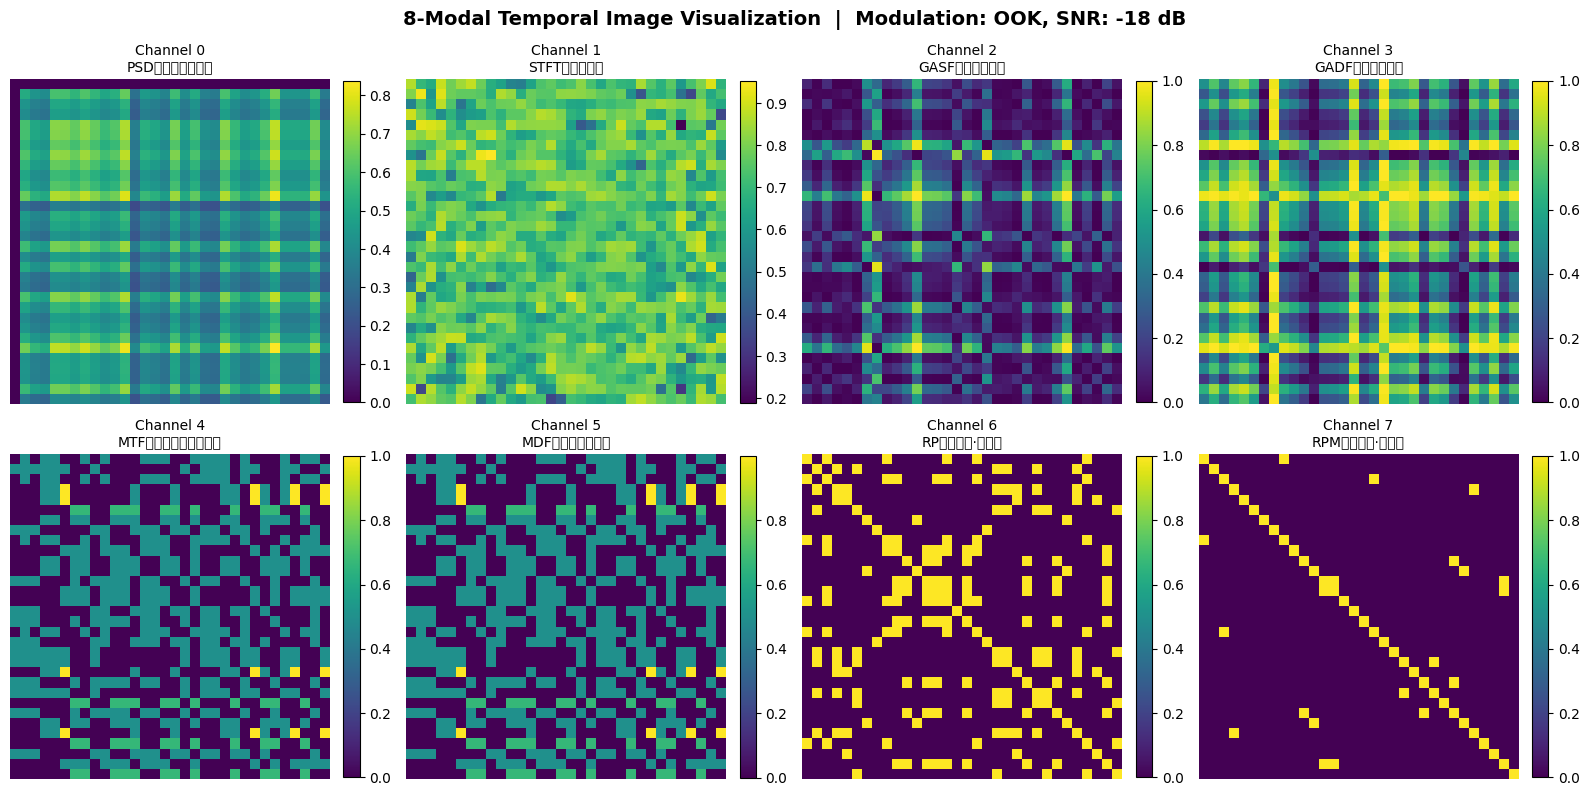

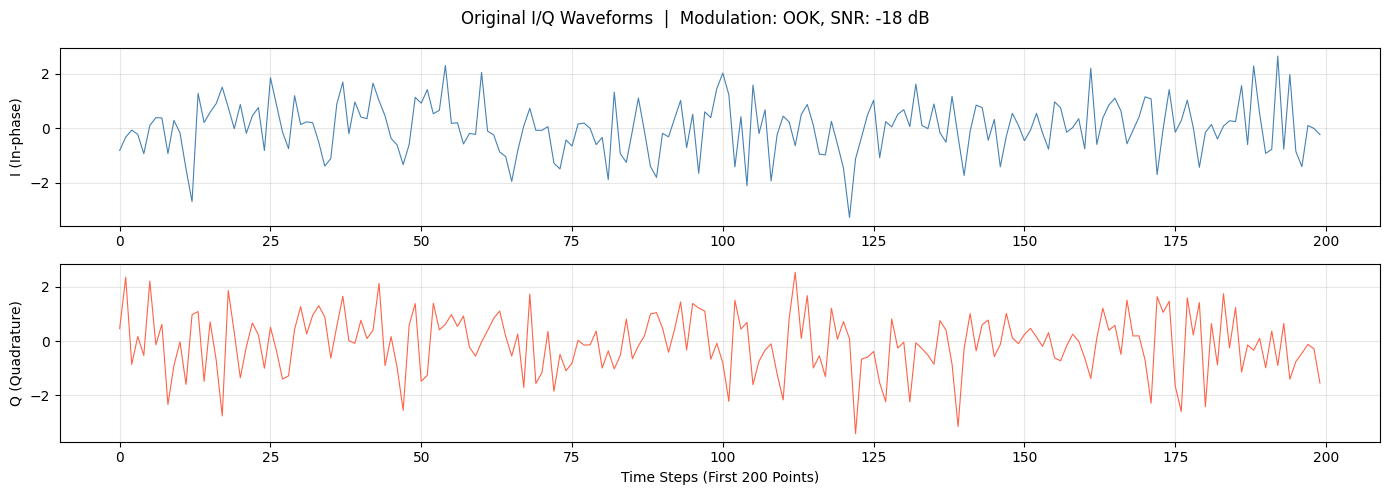

In [27]:
# ============================================================
# Cell 6: 可视化8种模态图像 (8-Modal Images Visualization)
# ============================================================

# 从HDF5读取一条样本做可视化
sample_rel_idx  = 500
sample_hdf5_row = int(selected_indices[sample_rel_idx])
mod_name = MOD_CLASSES[y_mod_sel[sample_rel_idx]]
snr_val  = snr_sel[sample_rel_idx]

with h5py.File(HDF5_PATH, 'r') as f:
    x_sample = f['X'][sample_hdf5_row]

if x_sample.shape == (2, 1024):
    x_sample = x_sample.T
x_sample = x_sample.astype(np.float32)
power    = float(np.mean(x_sample ** 2)) + 1e-8
x_sample = x_sample / np.sqrt(power)

print(f'样本信息：调制={mod_name}，SNR={snr_val} dB')

# 生成8种模态图像
imgs_8 = make_8modal_image(x_sample, IMG_SIZE)
print(f'多模态图像形状：{imgs_8.shape}  →  (8通道, 32×32)')

# ── 绘制8种模态 ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# 将标题更改为英文，避免Kaggle上中文显示为方块
fig.suptitle(f'8-Modal Temporal Image Visualization  |  Modulation: {mod_name}, SNR: {snr_val} dB',
             fontsize=14, fontweight='bold')

# 如果你的 MODAL_NAMES 定义的是中文（例如 ['瞬时振幅', ...]），
# 可以考虑在这里或者全局定义一个对应的英文名字映射列表，这里假设使用英文或索引展示。
# 如果 MODAL_NAMES 本身就是英文，则可以直接使用。
for i, (ax, name) in enumerate(zip(axes.flat, MODAL_NAMES)):
    im = ax.imshow(imgs_8[i], cmap='viridis', aspect='auto')
    ax.set_title(f'Channel {i}\n{name}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── 原始IQ波形 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
# 将标题及坐标轴标签更改为英文
fig.suptitle(f'Original I/Q Waveforms  |  Modulation: {mod_name}, SNR: {snr_val} dB', fontsize=12)
axes[0].plot(x_sample[:200, 0], lw=0.8, color='steelblue')
axes[0].set_ylabel('I (In-phase)')
axes[0].grid(alpha=0.3)

axes[1].plot(x_sample[:200, 1], lw=0.8, color='tomato')
axes[1].set_ylabel('Q (Quadrature)')
axes[1].set_xlabel('Time Steps (First 200 Points)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cell 7｜双模态 Dataset 设计

### 📖 按需读取（On-the-fly）策略

本实验采用**按需读取**而非预加载，彻底避免内存溢出问题：

```
DataLoader 请求第 idx 条样本
│
├── idx < n_hdf5  → 从 HDF5 按行读取 IQ 信号 → 实时生成 8 种模态图像
└── idx ≥ n_hdf5  → 从内存 AWGN 数组取数据 → 实时生成 8 种模态图像
```

### 🏗️ 双输入设计

每条样本同时返回两种表示，对应模型的两个分支：

| 输出变量 | 形状 | 用途 |
|---|---|---|
| `x_time` | `(1024, 4)` | BiLSTM 时域分支（I, Q, 幅度, 展开相位） |
| `x_img` | `(8, 32, 32)` | ResNet18 图像分支（8种模态） |
| `y` | scalar | H0/H1 标签（0或1） |

### 📐 功率归一化

消除不同信号绝对功率差异，使模型专注于调制方式的**波形形状**：

$$\hat{x}(t) = \frac{x(t)}{\sqrt{\dfrac{1}{T}\sum_t(I^2(t)+Q^2(t))+\varepsilon}}$$

In [28]:
# ============================================================
# Cell 7: 双模态 Dataset
# ============================================================

# ── 实例化四个数据集 ──────────────────────────────────────────
BATCH_SIZE = 64

def make_time_features(x):
    """
    构造 BiLSTM 时域输入：[I, Q, 瞬时幅度, 展开相位]

    输入 x: (1024, 2)
    输出  : (1024, 4)  逐通道标准化后的四维特征

    增加幅度和相位两个导出特征，让BiLSTM直接感知调制特征，
    np.unwrap 减少相位在 ±π 间跳变引入的人工突变。
    """
    I, Q  = x[:, 0], x[:, 1]
    amp   = np.sqrt(I**2 + Q**2)
    #unwrap：防止假的突变
    phase = np.unwrap(np.angle(I + 1j*Q))
    #把四个一维特征合并成一个二维矩阵
    feat  = np.stack([I, Q, amp, phase], axis=1).astype(np.float32)
    mean  = feat.mean(axis=0, keepdims=True)
    std   = feat.std(axis=0,  keepdims=True) + 1e-6
    return ((feat - mean) / std).astype(np.float32)

# 把 HDF5 里的真实 IQ 样本和你额外生成的 AWGN 纯噪声样本合在一起，构造成 PyTorch 可以训练的数据集。
class DualModalDataset(Dataset):
    """
    双模态频谱感知数据集：每条样本同时返回时域特征和多模态图像。

    参数:
        hdf5_positions  : 在 selected_indices 中的位置索引（来自HDF5的样本）
        hdf5_labels     : 对应的H0/H1标签
        awgn_data       : AWGN噪声数组 (M, 1024, 2)，H0负样本
        selected_indices: HDF5文件中的真实行号映射表
    """
    #初始化函数
    def __init__(self, hdf5_path, hdf5_positions, hdf5_labels,
             awgn_data, selected_indices, img_size=32, snr_sel=None):
        self.hdf5_path   = hdf5_path
        #把“子集位置编号”转换成“HDF5 文件真实行号”
        """
        比如：
        selected_indices = [100, 205, 380, 901]
        hdf5_positions = [0, 2]
        那么：
        selected_indices[hdf5_positions]
        得到：[100, 380]
        """
        self.hdf5_rows   = selected_indices[hdf5_positions].astype(np.int64)
        self.hdf5_labels = np.array(hdf5_labels, dtype=np.int64)
        # 保存每条 HDF5 样本对应的 SNR，后面只对低SNR H1做增强
        if snr_sel is not None:
            self.hdf5_snrs = np.array(snr_sel[hdf5_positions], dtype=np.int64)
        else:
            self.hdf5_snrs = np.zeros(len(hdf5_positions), dtype=np.int64)
        # 保存 AWGN 噪声数据，并给 AWGN 全部打标签 0。
        self.awgn_data   = awgn_data
        self.awgn_labels = np.zeros(len(awgn_data), dtype=np.int64)
        #记录数量
        self.n_hdf5      = len(self.hdf5_rows)
        self.n_awgn      = len(self.awgn_data)
        self.total       = self.n_hdf5 + self.n_awgn
        self.img_size    = img_size
        self._f          = None
        self.training    = True   # 默认训练模式

    #不用重复打开
    def _open(self):
        if self._f is None:
            self._f = h5py.File(self.hdf5_path, 'r')

    def __len__(self): return self.total

    def __getitem__(self, idx):
        if idx < self.n_hdf5:
            self._open()
            x = self._f['X'][int(self.hdf5_rows[idx])]
            #T代表转置
            if x.shape == (2, 1024): x = x.T
            elif x.shape != (1024, 2): x = x.reshape(1024, 2)
            y = int(self.hdf5_labels[idx])
        else:
            x = self.awgn_data[idx - self.n_hdf5]
            y = 0

        x = np.asarray(x, dtype=np.float32)
        power = float(np.mean(x ** 2)) + 1e-8
        x = x / np.sqrt(power)   # 功率归一化

        # ── 温和低SNR增强：只对低SNR H1样本加轻微噪声 ───────────────
        snr = int(self.hdf5_snrs[idx]) if idx < self.n_hdf5 else H0_SNR

        if self.training and y == 1 and snr <= -10 and np.random.rand() < 0.10:
            # 只对更低SNR的H1样本做轻微增强，避免过度破坏H1结构并推高Pfa
            extra_snr_drop = np.random.uniform(1, 3)

            sigma_extra = np.sqrt(10 ** (extra_snr_drop / 10) - 1) * np.sqrt(0.5)

            x = x + (np.random.randn(*x.shape) * sigma_extra).astype(np.float32)

            # 重新归一化
            power = float(np.mean(x ** 2)) + 1e-8
            x = x / np.sqrt(power)

        x_time = make_time_features(x)            # (1024, 4)
        x_img  = make_8modal_image(x, self.img_size)  # (8, 32, 32)

        return (torch.from_numpy(x_time),
                torch.from_numpy(x_img),
                torch.tensor(y, dtype=torch.long))

    """
    返回三样东西 x_time：时域序列特征、x_img ：多模态图像特征、y：H0/H1 标签
    """
    def __del__(self):
        if self._f is not None:
            try: self._f.close()
            except: pass


# ── 实例化四个数据集 ──────────────────────────────────────────
def _make_ds(h1_pos, h0d_pos, awgn_arr):
    return DualModalDataset(
        HDF5_PATH,
        np.concatenate([h1_pos, h0d_pos]),
        np.concatenate([
            np.ones(len(h1_pos), dtype=np.int64),
            np.zeros(len(h0d_pos), dtype=np.int64)
        ]),
        awgn_arr,
        selected_indices,
        IMG_SIZE,
        snr_sel=snr_sel
    )

#训练集
train_ds  = _make_ds(train_h1_pos, train_h0d_pos, train_awgn)
#验证集
val_ds    = _make_ds(val_h1_pos,   val_h0d_pos,   val_awgn)
#测试集1
test1_ds = DualModalDataset(
    HDF5_PATH,
    t1_h1_pos,
    np.ones(len(t1_h1_pos), dtype=np.int64),
    awgn_t1,
    selected_indices,
    IMG_SIZE,
    snr_sel=snr_sel
)
#测试集2
test2_ds  = _make_ds(t2_h1_pos, t2_h0d_pos, awgn_t2)

# ============================================================
# 是否启用低SNR加噪增强
# ============================================================
# 只允许训练集做数据增强。
# 因为训练集用于让模型学习，所以可以随机加噪，增强低SNR样本。
train_ds.training = True

# 验证集和测试集必须关闭增强。
# 因为验证集和测试集用于评估模型性能，不能随机改变数据。
# 否则每次测试的数据都不一样，结果不稳定，也不公平。
val_ds.training   = False
test1_ds.training = False
test2_ds.training = False

def make_low_snr_h1_sampler(ds):
    """
    低SNR H1分级过采样：
    让模型更多看到低SNR有信号样本，提高低SNR下的Pd。
    """
    weights = []

    for idx in range(len(ds)):
        if idx < ds.n_hdf5:
            y = int(ds.hdf5_labels[idx])
            snr = int(ds.hdf5_snrs[idx])
        else:
            y = 0
            snr = H0_SNR

        w = 1.0

        if y == 1:
            if snr <= -12:
                w = 2.0
            elif snr <= -8:
                w = 1.6
            elif snr <= -4:
                w = 1.3

        weights.append(w)

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

train_sampler = make_low_snr_h1_sampler(train_ds)

#DataLoader 的作用是：把 Dataset 里的数据按 batch 批量取出来。
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test1_loader = DataLoader(test1_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test2_loader = DataLoader(test2_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('✅ 双模态 Dataset & DataLoader 构建完成！')
print(f'  训练集: {len(train_ds):,}  验证集: {len(val_ds):,}')
print(f'  测试集1: {len(test1_ds):,}  测试集2: {len(test2_ds):,}')

# Sanity check：打印一个batch的形状
xt, xi, yb = next(iter(train_loader))
print(f'\n一批数据形状验证:')
print(f'  x_time : {xt.shape}   (B×1024×4，BiLSTM输入)')
print(f'  x_img  : {xi.shape}  (B×8×32×32，ResNet18输入)')
print(f'  y      : {yb.shape}  | H1={yb.sum().item()}  H0={(yb==0).sum().item()}')
print(f'  值域验证: x_time∈[{xt.min():.2f},{xt.max():.2f}]  x_img∈[{xi.min():.2f},{xi.max():.2f}]')


✅ 双模态 Dataset & DataLoader 构建完成！
  训练集: 129,023  验证集: 32,257
  测试集1: 107,520  测试集2: 192,000

一批数据形状验证:
  x_time : torch.Size([64, 1024, 4])   (B×1024×4，BiLSTM输入)
  x_img  : torch.Size([64, 8, 32, 32])  (B×8×32×32，ResNet18输入)
  y      : torch.Size([64])  | H1=41  H0=23
  值域验证: x_time∈[-5.71,4.73]  x_img∈[0.00,1.00]


---
## Cell 8｜双分支网络架构：BiLSTM + ResNet18 + 双向交叉注意力

### 📖 整体架构

$$\underbrace{x_{\text{time}}}_{(B,1024,4)} \xrightarrow{\text{2层BiLSTM+MeanPool}} f_{\text{time}} \in \mathbb{R}^{B\times D}$$

$$\underbrace{x_{\text{img}}}_{(B,8,32,32)} \xrightarrow{\text{ResNet18（修改首层）}} f_{\text{img}} \in \mathbb{R}^{B\times D}$$

$$f_{\text{time}},\, f_{\text{img}} \xrightarrow{\text{BCA门控融合}} \tilde{f}_{\text{time}},\,\tilde{f}_{\text{img}} \xrightarrow{\text{拼接+MLP}} \hat{y}$$

---

### 🧠 分支1：两层双向 LSTM（BiLSTM）

BiLSTM 同时从正向和反向处理 IQ 时序，捕获双向时序依赖：

$$\overrightarrow{h}_t = \mathrm{LSTM}(x_t, \overrightarrow{h}_{t-1}), \quad \overleftarrow{h}_t = \mathrm{LSTM}(x_t, \overleftarrow{h}_{t+1}), \quad h_t = [\overrightarrow{h}_t;\, \overleftarrow{h}_t]$$

使用 **Mean Pooling** 而非只取最后时间步，完整利用 1024 步的序列信息：

$$f_{\text{time}} = \frac{1}{T}\sum_{t=1}^{T} h_t$$

---

### 🖼️ 分支2：预训练 ResNet18（修改首层卷积）

ResNet18 原设计接受 3 通道 RGB 输入，本实验输入为 **8 通道**多模态图像。
将 `conv1` 修改为 $8\to 64$ 通道，其余层**保留 ImageNet 预训练权重**：

$$\text{conv1\_new}: (8, 3, 3) \xrightarrow{\text{均值初始化}} \text{继承预训练特征语义}$$

---

### 🔀 双向交叉注意力（BCA）+ 门控融合

**双向**：Time→Image 和 Image→Time 同时进行，实现**相互感知**：

$$\text{Attn}_{t\to i} = \mathrm{softmax}\!\left(\frac{Q_t K_i^\top}{\sqrt{D}}\right)V_i, \quad \text{Attn}_{i\to t} = \mathrm{softmax}\!\left(\frac{Q_i K_t^\top}{\sqrt{D}}\right)V_t$$

**门控残差**：可学习标量 $\alpha$ 控制交叉注意力贡献，初始化为0让模型先学单模态特征：

$$\tilde{f}_{\text{time}} = \mathrm{LayerNorm}\!\left(f_{\text{time}} + \sigma(\alpha_t)\cdot\text{Attn}_{t\to i}\right)$$
$$\tilde{f}_{\text{img}}  = \mathrm{LayerNorm}\!\left(f_{\text{img}}  + \sigma(\alpha_i)\cdot\text{Attn}_{i\to t}\right)$$

In [29]:
# ============================================================
# Cell 8: 双分支网络 + 双向交叉注意力
# ============================================================

# ── 分支1：两层 BiLSTM + MeanPool ────────────────────────────
class BiLSTMBranch(nn.Module):
    """
    时域特征提取：两层双向LSTM + 均值池化投影。

    输入  x_time: (B, 1024, 4)
    输出  feat  : (B, emb_dim)
    """
    """
    input_size=4：每个时间点输入 4 个特征
    hidden_size=128：LSTM 单向隐藏状态维度是 128
    emb_dim=256：最后输出的时域特征维度是 256
    dropout=0.3：训练时随机丢弃一部分神经元，防止过拟合
    """
    def __init__(self, input_size=4, hidden_size=128, emb_dim=256, dropout=0.3):
        super().__init__()
        """
            num_layers=2
            表示堆叠两层 LSTM。
            可以理解成：
            第一层 BiLSTM 提取较浅的时序变化特征
            第二层 BiLSTM 在第一层基础上提取更高层的时序结构
        """

        """
        batch_first=True
        就是告诉 LSTM：
        我的输入格式是 (batch, time, feature) 不是 (time, batch, feature)
        """
        self.bilstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        # 把 BiLSTM 提取到的特征再处理一下，变成最终的时域嵌入向量。
        self.proj = nn.Sequential(
            # 归一化特征，让训练更稳定。
            nn.LayerNorm(hidden_size * 2),
            # 全连接层 把 BiLSTM 的输出特征映射到你想要的统一特征维度 可以改变维度，也可以重新变换特征
            nn.Linear(hidden_size * 2, emb_dim),
            # 加入非线性，让模型能表达更复杂的关系。
            nn.ReLU(), nn.Dropout(dropout)
        )

    def forward(self, x):
        out, _ = self.bilstm(x)          # (B, T, 2*hidden)
        # dim=1 是时间维度，也就是 1024 个采样点。 把 1024 个时间点的 BiLSTM 特征平均成一个整体特征。
        feat   = out.mean(dim=1)         # Mean Pooling: (B, 2*hidden)
        return self.proj(feat)           # (B, emb_dim)


class ChannelAttention(nn.Module):
    """
    SE（Squeeze-and-Excitation）通道注意力。

    对8个输入模态通道做全局池化后，用MLP学习每个通道的重要性权重。
    低SNR时，PSD/STFT图像质量差，注意力权重会自动降低其影响。

    输入  x: (B, 8, 32, 32)
    输出  x': (B, 8, 32, 32)  通道加权后的图像
    """
    def __init__(self, in_channels=8, reduction=2):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, max(1, in_channels // reduction)),
            nn.ReLU(),
            nn.Linear(max(1, in_channels // reduction), in_channels),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, _, _ = x.shape
        # 平均池化 + 最大池化双路特征
        avg = self.fc(self.avg_pool(x).view(B, C))
        mx  = self.fc(self.max_pool(x).view(B, C))
        # 通道权重
        w   = self.sigmoid(avg + mx).view(B, C, 1, 1)
        return x * w   # 通道加权


# ── 分支2：预训练 ResNet18（8通道输入）───────────────────────
class ResNet18Branch(nn.Module):
    """
    图像特征提取：修改首层卷积以接受8通道多模态图像。

    输入  x_img: (B, 8, 32, 32)
    输出  feat : (B, emb_dim)
    """
    def __init__(self, in_channels=8, emb_dim=256, dropout=0.3, pretrained=True):
        super().__init__()
        # ← 新增通道注意力，在送入ResNet之前对8个模态做加权
        self.ch_attn = ChannelAttention(in_channels, reduction=2)

        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet18(weights=weights)
        old = backbone.conv1
        backbone.conv1 = nn.Conv2d(
            in_channels, old.out_channels,
            kernel_size=old.kernel_size, stride=old.stride,
            padding=old.padding, bias=False
        )
        with torch.no_grad():
            backbone.conv1.weight[:] = (
                old.weight.mean(dim=1, keepdim=True).expand_as(backbone.conv1.weight)
            )
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = self.ch_attn(x)           # ← 先做通道注意力加权
        return self.proj(self.backbone(x))


# ── 双向交叉注意力 + 样本自适应门控融合 ─────────────────────────────
class BidirectionalCrossAttention(nn.Module):
    """
    改进版 BCA：全局双向交叉融合 + 样本自适应门控。

    输入:
        f_time: (B, D)
        f_img : (B, D)

    输出:
        f_time_out: (B, D)
        f_img_out : (B, D)

    改进点:
        原版 gate_t/gate_i 是全局标量，所有样本共用；
        这里改成根据当前样本的特征动态生成 gate，
        让不同 SNR、不同调制方式的样本可以有不同的融合强度。
    """

    def __init__(self, emb_dim=256, dropout=0.1):
        super().__init__()

        self.scale = emb_dim ** -0.5

        # Time query, Image key/value
        self.q_t = nn.Linear(emb_dim, emb_dim)
        self.k_i = nn.Linear(emb_dim, emb_dim)
        self.v_i = nn.Linear(emb_dim, emb_dim)

        # Image query, Time key/value
        self.q_i = nn.Linear(emb_dim, emb_dim)
        self.k_t = nn.Linear(emb_dim, emb_dim)
        self.v_t = nn.Linear(emb_dim, emb_dim)

        # ====================================================
        # 核心改进：动态门控，而不是固定标量 gate
        # ====================================================
        # gate_t: 控制“图像补充信息”加到时域特征里多少
        self.gate_t_net = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim),
            nn.Sigmoid()
        )

        # gate_i: 控制“时域补充信息”加到图像特征里多少
        self.gate_i_net = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim),
            nn.Sigmoid()
        )

        self.norm_t = nn.LayerNorm(emb_dim)
        self.norm_i = nn.LayerNorm(emb_dim)

        self.drop = nn.Dropout(dropout)

    def _cross_attn(self, q_proj, k_proj, v_proj, fq, fkv):
        """
        单方向交叉注意力。
        当前仍然是全局向量级 BCA，因此输入是 (B, D)。
        """
        Q = q_proj(fq.unsqueeze(1))     # (B, 1, D)
        K = k_proj(fkv.unsqueeze(1))    # (B, 1, D)
        V = v_proj(fkv.unsqueeze(1))    # (B, 1, D)

        attn = torch.softmax(
            Q @ K.transpose(-2, -1) * self.scale,
            dim=-1
        )                              # (B, 1, 1)

        ctx = (attn @ V).squeeze(1)     # (B, D)

        # Dropout 放在上下文特征上，比直接放在单个注意力权重上更稳
        ctx = self.drop(ctx)

        return ctx

    def forward(self, f_time, f_img):
        # ====================================================
        # 1. 时域特征从图像特征中获取补充信息
        # ====================================================
        ctx_ti = self._cross_attn(
            self.q_t,
            self.k_i,
            self.v_i,
            f_time,
            f_img
        )  # (B, D)

        # ====================================================
        # 2. 图像特征从时域特征中获取补充信息
        # ====================================================
        ctx_it = self._cross_attn(
            self.q_i,
            self.k_t,
            self.v_t,
            f_img,
            f_time
        )  # (B, D)

        # ====================================================
        # 3. 根据当前样本动态生成门控权重
        # ====================================================
        gate_t = self.gate_t_net(
            torch.cat([f_time, ctx_ti], dim=1)
        )  # (B, D)

        gate_i = self.gate_i_net(
            torch.cat([f_img, ctx_it], dim=1)
        )  # (B, D)

        # ====================================================
        # 4. 门控残差融合
        # ====================================================
        f_time_out = self.norm_t(
            f_time + gate_t * ctx_ti
        )

        f_img_out = self.norm_i(
            f_img + gate_i * ctx_it
        )

        return f_time_out, f_img_out


# ── 完整双分支融合网络 ────────────────────────────────────────
class DualBranchSpectrumNet(nn.Module):
    """
    双分支多模态频谱感知网络。

    输入: x_time (B,1024,4) + x_img (B,8,32,32)
    输出: logits (B,2)
    """
    def __init__(self, emb_dim=256, num_classes=2, dropout=0.3):
        super().__init__()
        self.time_branch = BiLSTMBranch(4, 128, emb_dim, dropout)
        self.img_branch  = ResNet18Branch(8, emb_dim, dropout, pretrained=True)
        self.bca         = BidirectionalCrossAttention(emb_dim, dropout=0.1)
        self.classifier  = nn.Sequential(
            #全连接层
            nn.Linear(emb_dim * 2, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x_time, x_img):
        f_time = self.time_branch(x_time)
        f_img  = self.img_branch(x_img)

        # 在BCA之前加Dropout（防止两个分支的特征过度适应训练集）
        f_time = F.dropout(f_time, p=0.05, training=self.training)
        f_img  = F.dropout(f_img,  p=0.05, training=self.training)

        f_time, f_img = self.bca(f_time, f_img)
        fused = torch.cat([f_time, f_img], 1)
        return self.classifier(fused)         # (B, 2)


# ── 实例化 & 参数统计 ─────────────────────────────────────────
#时域分支和图像分支最后都输出 256 维特征。
EMB_DIM = 256
model   = DualBranchSpectrumNet(emb_dim=EMB_DIM, num_classes=2, dropout=0.3).to(DEVICE)

total   = sum(p.numel() for p in model.parameters())
trainp  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ 模型实例化完成！')
print(f'   总参数量   : {total:,}')
print(f'   可训练参数 : {trainp:,}')
print('\nBCA门控方式:')
print('   当前为样本自适应动态门控，不再使用固定 gate_t/gate_i 标量。')
print('   gate_t/gate_i 会在 forward 中由当前样本特征生成，形状约为 (B, 256)。')
print('\n模型结构:')
print(model)


✅ 模型实例化完成！
   总参数量   : 12,844,238
   可训练参数 : 12,844,238

BCA门控方式:
   当前为样本自适应动态门控，不再使用固定 gate_t/gate_i 标量。
   gate_t/gate_i 会在 forward 中由当前样本特征生成，形状约为 (B, 256)。

模型结构:
DualBranchSpectrumNet(
  (time_branch): BiLSTMBranch(
    (bilstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (proj): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
  )
  (img_branch): ResNet18Branch(
    (ch_attn): ChannelAttention(
      (avg_pool): AdaptiveAvgPool2d(output_size=1)
      (max_pool): AdaptiveMaxPool2d(output_size=1)
      (fc): Sequential(
        (0): Linear(in_features=8, out_features=4, bias=True)
        (1): ReLU()
        (2): Linear(in_features=4, out_features=8, bias=True)
      )
      (sigmoid): Sigmoid()
    )
    (backbone): Sequential(
      (0): Conv2d(8, 64, kernel_size=(7, 7), stride=(2, 2), 

---
## Cell 9｜训练循环

### 📖 优化策略

**差异化学习率**：预训练 ResNet18 使用更小的学习率，保护已有知识；
新模块（BiLSTM、BCA、分类头）使用较大学习率从头学习：

| 参数组 | 学习率 | 原因 |
|---|---|---|
| BiLSTM | $10^{-3}$ | 从头训练，需要较大步长 |
| ResNet18 | $10^{-4}$ | 预训练权重微调，步长要小 |
| BCA + 分类头 | $10^{-3}$ | 新模块，从头训练 |

**梯度裁剪**：限制 L2 范数上界，防止 BiLSTM 梯度爆炸：

$$\text{if } \|g\|_2 > 1.0: \quad g \leftarrow \frac{g}{\|g\|_2}$$

**ReduceLROnPlateau**：验证损失连续 2 个 epoch 不下降时，学习率 ×0.5。

In [30]:
# ============================================================
# Cell 9: 训练循环（强烈推荐版：按 Pfa≤5% 下 Pd 保存最优模型）
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

optimizer = optim.AdamW([
    {'params': model.time_branch.parameters(),  'lr': 8e-4, 'weight_decay': 1e-4},
    {'params': model.img_branch.parameters(),   'lr': 1e-4, 'weight_decay': 5e-5},
    {'params': model.bca.parameters(),          'lr': 8e-4, 'weight_decay': 1e-4},
    {'params': model.classifier.parameters(),   'lr': 8e-4, 'weight_decay': 1e-4},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for x_time, x_img, yb in loader:
            x_time = x_time.to(device, non_blocking=True)
            x_img  = x_img.to(device, non_blocking=True)
            yb     = yb.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad()

            logits = model(x_time, x_img)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            pred = logits.argmax(dim=1)

            total_correct += (pred == yb).sum().item()
            total_loss += loss.item() * len(yb)
            total_n += len(yb)

    return total_loss / total_n, total_correct / total_n


def collect_val_probs_fast(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_time, x_img, yb in loader:
            x_time = x_time.to(device, non_blocking=True)
            x_img  = x_img.to(device, non_blocking=True)

            logits = model(x_time, x_img)
            probs_h1 = F.softmax(logits, dim=1)[:, 1]

            all_probs.append(probs_h1.cpu().numpy())
            all_labels.append(yb.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)


def np_score_under_pfa(probs_h1, labels, max_pfa=0.05):
    """
    在验证集上找 Pfa≤max_pfa 时的最大 Pd。
    返回:
        best_pd, best_pfa, best_threshold
    """
    thresholds = np.linspace(0.01, 0.99, 500)

    best_pd = -1.0
    best_pfa = 1.0
    best_th = 0.5

    labels = labels.astype(np.int64)

    for th in thresholds:
        preds = (probs_h1 >= th).astype(np.int64)

        cm = confusion_matrix(labels, preds, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()

        pd = TP / (TP + FN + 1e-12)
        pfa = FP / (FP + TN + 1e-12)

        if pfa <= max_pfa:
            if pd > best_pd:
                best_pd = pd
                best_pfa = pfa
                best_th = th

    return best_pd, best_pfa, best_th


NUM_EPOCHS = 50
EARLY_STOP = 6

best_np_pd = -1.0
best_np_pfa = 1.0
best_np_th = 0.5

best_state = None
best_epoch = 0
no_improve = 0

history = {
    'tr_loss': [],
    'val_loss': [],
    'tr_acc': [],
    'val_acc': [],
    'val_np_pd': [],
    'val_np_pfa': [],
    'val_np_th': []
}

print(f'🚀 开始训练 | 上限{NUM_EPOCHS} epoch | 早停={EARLY_STOP} | 设备: {DEVICE}')
print(f'{"Ep":>4}|{"TrLoss":>9}|{"TrAcc":>8}|{"ValLoss":>9}|{"ValAcc":>8}|{"ValPd@5%":>10}|{"Pfa":>8}|{"Th":>7}|{"LR":>10}')
print('-' * 92)

for ep in range(1, NUM_EPOCHS + 1):
    tr_l, tr_a = run_epoch(model, train_loader, criterion, optimizer, DEVICE, train=True)
    vl_l, vl_a = run_epoch(model, val_loader, criterion, optimizer, DEVICE, train=False)

    val_probs_tmp, val_labels_tmp = collect_val_probs_fast(model, val_loader, DEVICE)
    val_np_pd, val_np_pfa, val_np_th = np_score_under_pfa(
        val_probs_tmp,
        val_labels_tmp,
        max_pfa=0.05
    )

    history['tr_loss'].append(tr_l)
    history['val_loss'].append(vl_l)
    history['tr_acc'].append(tr_a)
    history['val_acc'].append(vl_a)
    history['val_np_pd'].append(val_np_pd)
    history['val_np_pfa'].append(val_np_pfa)
    history['val_np_th'].append(val_np_th)

    star = ''

    # 核心修改：按 Pfa≤5% 条件下的 Pd 保存最优模型
    if val_np_pd > best_np_pd:
        best_np_pd = val_np_pd
        best_np_pfa = val_np_pfa
        best_np_th = val_np_th
        best_epoch = ep

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        no_improve = 0
        star = ' ⭐'
    else:
        no_improve += 1

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(vl_l)
    new_lr = optimizer.param_groups[0]['lr']

    lr_flag = f'⬇ {old_lr:.1e}->{new_lr:.1e}' if new_lr < old_lr else ''

    print(
        f'{ep:>4}|'
        f'{tr_l:>9.4f}|'
        f'{tr_a:>7.2%}|'
        f'{vl_l:>9.4f}|'
        f'{vl_a:>7.2%}|'
        f'{val_np_pd:>9.2%}|'
        f'{val_np_pfa:>7.2%}|'
        f'{val_np_th:>7.3f}|'
        f'{new_lr:>10.2e} {star} {lr_flag}'
    )

    if no_improve >= EARLY_STOP:
        print(f'\n⛔ Early Stop: 连续 {EARLY_STOP} 个 epoch 的 Val Pd@Pfa≤5% 没有提升')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

    print('\n🏆 训练结束！')
    print(f'最优 Epoch = {best_epoch}')
    print(f'最优 Val Pd@Pfa≤5% = {best_np_pd:.2%}')
    print(f'对应 Val Pfa = {best_np_pfa:.2%}')
    print(f'对应阈值 ≈ {best_np_th:.3f}')
else:
    print('\n⚠️ 没有保存 best_state，请检查训练过程。')

🚀 开始训练 | 上限50 epoch | 早停=6 | 设备: cuda
  Ep|   TrLoss|   TrAcc|  ValLoss|  ValAcc|  ValPd@5%|     Pfa|     Th|        LR
--------------------------------------------------------------------------------------------
   1|   0.4628| 77.77%|   0.3814| 85.00%|   77.80%|  4.98%|  0.629|  8.00e-04  ⭐ 
   2|   0.4246| 80.74%|   0.3759| 87.02%|   78.78%|  4.97%|  0.472|  8.00e-04  ⭐ 
   3|   0.4115| 81.64%|   0.3742| 84.39%|   78.65%|  4.95%|  0.629|  8.00e-04  
   4|   0.3995| 82.48%|   0.3768| 85.71%|   78.42%|  4.98%|  0.568|  8.00e-04  
   5|   0.3817| 83.91%|   0.3887| 85.50%|   78.09%|  4.99%|  0.688|  8.00e-04  
   6|   0.3544| 86.09%|   0.3994| 83.51%|   77.42%|  4.99%|  0.733|  4.00e-04  ⬇ 8.0e-04->4.0e-04
   7|   0.2991| 89.70%|   0.4618| 83.74%|   76.75%|  4.96%|  0.872|  4.00e-04  
   8|   0.2629| 91.91%|   0.5016| 83.18%|   76.75%|  4.95%|  0.951|  4.00e-04  

⛔ Early Stop: 连续 6 个 epoch 的 Val Pd@Pfa≤5% 没有提升

🏆 训练结束！
最优 Epoch = 2
最优 Val Pd@Pfa≤5% = 78.78%
对应 Val Pfa = 4.97%
对应阈值 ≈ 0.

---
## Cell 10｜训练曲线可视化

### 📖 曲线诊断指南

| 曲线形态 | 诊断 | 建议处理 |
|---|---|---|
| Train↓, Val↓ 同步 | 正常收敛 | 可继续训练或早停 |
| Train↓, Val↑ | **过拟合** | 加大Dropout，数据增强 |
| Train/Val 均不动 | 梯度消失或LR过小 | 调大LR，检查BatchNorm |
| 两条曲线剧烈震荡 | LR过大 | 降低学习率 |

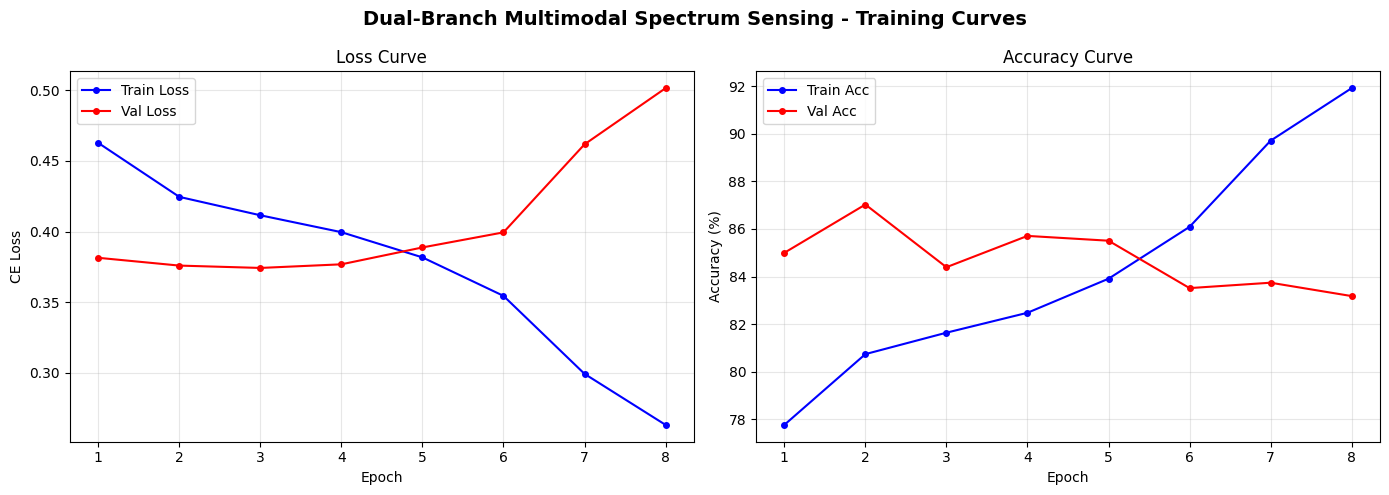

In [31]:
# ============================================================
# Cell 10: 训练曲线可视化
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dual-Branch Multimodal Spectrum Sensing - Training Curves', fontsize=14, fontweight='bold')
eps = range(1, len(history['tr_loss']) + 1)

axes[0].plot(eps, history['tr_loss'], 'b-o', ms=4, label='Train Loss')
axes[0].plot(eps, history['val_loss'], 'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, [x*100 for x in history['tr_acc']], 'b-o', ms=4, label='Train Acc')
axes[1].plot(eps, [x*100 for x in history['val_acc']], 'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Cell 11｜推理函数 & 评估指标定义

### 📖 频谱感知核心评估指标

| 指标 | 公式 | 含义 |
|---|---|---|
| **Pd（检测概率）** | $P_d = \dfrac{TP}{TP+FN}$ | H1 被正确检测为 H1 的概率，越高越好 |
| **Pfa（虚警概率）** | $P_{fa} = \dfrac{FP}{FP+TN}$ | H0 被误判为 H1 的概率，越低越好 |
| **AUC** | ROC曲线下面积 | 检测器综合性能，1为完美 |
| **F1-score** | $\dfrac{2PR}{P+R}$ | 精确率与召回率调和均值 |

### 🎯 Neyman-Pearson 准则

工程实践中约束虚警概率 $P_{fa} \leq \alpha_0$（如 0.1），在此约束下最大化检测概率：

$$\max_{T} P_d \quad \text{s.t.} \quad P_{fa} \leq 0.1$$

实现方法：先在全局 ROC 曲线上找满足 $P_{fa} \leq 0.1$ 的最优判决阈值 $T^*$，再按 SNR 分组统计 $P_d$。

In [32]:
# ============================================================
# Cell 11: 阈值优化 + 验证集/测试集评估
# ============================================================



def collect_probs_and_labels(model, loader, device):
    """
    收集模型在某个数据集上的 H1 概率和真实标签。

    之前如果用 logits.argmax(1)，相当于固定阈值 0.5。
    现在改成先保存 H1 概率，后面再根据阈值判断 H0/H1。

    返回:
        probs_h1 : 每个样本属于 H1 的概率，shape=(N,)
        labels   : 真实标签，0=H0，1=H1，shape=(N,)
    """
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:

            # 兼容 Dataset 返回 3 个量或 4 个量的情况
            # 3个量: x_time, x_img, yb
            # 4个量: x_time, x_img, yb, snr
            if len(batch) == 3:
                x_time, x_img, yb = batch
            elif len(batch) == 4:
                x_time, x_img, yb, _ = batch
            else:
                raise ValueError(f'当前 batch 返回了 {len(batch)} 个元素，请检查 Dataset.__getitem__')

            x_time = x_time.to(device, non_blocking=True)
            x_img  = x_img.to(device,  non_blocking=True)
            yb     = yb.to(device,     non_blocking=True)

            logits = model(x_time, x_img)

            # softmax 后取第 1 类，也就是 H1 的概率
            probs_h1 = F.softmax(logits, dim=1)[:, 1]

            all_probs.append(probs_h1.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    probs_h1 = np.concatenate(all_probs)
    labels   = np.concatenate(all_labels)

    return probs_h1, labels


def compute_metrics_by_threshold(probs_h1, labels, threshold=0.5):
    """
    给定阈值，计算 Accuracy、F1、Pd、Pfa、AUC。

    判决规则:
        probs_h1 >= threshold  判为 H1
        probs_h1 <  threshold  判为 H0
    """
    labels = labels.astype(np.int64)

    preds = (probs_h1 >= threshold).astype(np.int64)

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, zero_division=0)

    # Pd = 检测概率 = 真实 H1 中被正确判为 H1 的比例
    Pd = TP / (TP + FN + 1e-12)

    # Pfa = 虚警概率 = 真实 H0 中被误判为 H1 的比例
    Pfa = FP / (FP + TN + 1e-12)

    # AUC 与单一阈值无关，看整体区分能力
    fpr, tpr, _ = roc_curve(labels, probs_h1)
    AUC = auc(fpr, tpr)

    return {
    'threshold': threshold,
    'acc': acc,
    'f1': f1,
    'Pd': Pd,
    'Pfa': Pfa,
    'AUC': AUC,
    'auc': AUC,       # 兼容后面旧代码里的 m["auc"]
    'cm': cm,
    'fpr': fpr,
    'tpr': tpr,
    'preds': preds
}


def find_best_threshold_on_val(probs_h1, labels, max_pfa=0.05):
    """
    在验证集上搜索两个阈值：

    1. acc_best_threshold:
       让验证集 Accuracy 最大的阈值。

    2. pd_best_threshold:
       在 Pfa <= max_pfa 的前提下，让 Pd 最大的阈值。
       这个更符合频谱感知任务。
    """
    thresholds = np.linspace(0.01, 0.99, 1000)

    acc_best_threshold = 0.5
    acc_best_result = None

    pd_best_threshold = 0.5
    pd_best_result = None

    for th in thresholds:
        result = compute_metrics_by_threshold(
            probs_h1=probs_h1,
            labels=labels,
            threshold=th
        )

        # 目标1：Accuracy 最大
        if acc_best_result is None or result['acc'] > acc_best_result['acc']:
            acc_best_result = result
            acc_best_threshold = th

        # 目标2：Pfa <= max_pfa 条件下，Pd 最大
        if result['Pfa'] <= max_pfa:
            if pd_best_result is None or result['Pd'] > pd_best_result['Pd']:
                pd_best_result = result
                pd_best_threshold = th

    # 如果没有找到满足 Pfa 约束的阈值，就退回默认 0.5
    if pd_best_result is None:
        pd_best_threshold = 0.5
        pd_best_result = compute_metrics_by_threshold(
            probs_h1=probs_h1,
            labels=labels,
            threshold=0.5
        )
        print(f'⚠️ 没有找到满足 Pfa <= {max_pfa:.2%} 的阈值，退回 threshold=0.5')

    return acc_best_threshold, acc_best_result, pd_best_threshold, pd_best_result


def print_eval_report(name, probs_h1, labels, threshold):
    """
    用指定阈值打印完整评估结果。
    """
    result = compute_metrics_by_threshold(
        probs_h1=probs_h1,
        labels=labels,
        threshold=threshold
    )

    print('\n' + '=' * 62)
    print(f'📊 {name} | threshold = {threshold:.3f}')
    print('=' * 62)

    print(f'  Accuracy : {result["acc"]:.4f}  |  F1-score: {result["f1"]:.4f}')
    print(f'  Pd       : {result["Pd"]:.4f}   (检测概率 TP/P)')
    print(f'  Pfa      : {result["Pfa"]:.4f}  (虚警概率 FP/N)')
    print(f'  AUC      : {result["AUC"]:.4f}')

    print(classification_report(
        labels,
        result['preds'],
        labels=[0, 1],
        target_names=['H0（噪声）', 'H1（信号）'],
        digits=4,
        zero_division=0
    ))

    return result


# ============================================================
# 1. 先收集验证集概率
# ============================================================

val_probs_h1, val_labels = collect_probs_and_labels(
    model=model,
    loader=val_loader,
    device=DEVICE
)


# ============================================================
# 2. 在验证集上搜索阈值
# ============================================================

acc_th, acc_result, pd_th, pd_result = find_best_threshold_on_val(
    probs_h1=val_probs_h1,
    labels=val_labels,
    max_pfa=0.05
)

print('\n🎯 验证集阈值搜索结果:')

print(f'\n[1] Accuracy 最优阈值: threshold = {acc_th:.3f}')
print(f'    Val Acc = {acc_result["acc"]:.4f}')
print(f'    Val Pd  = {acc_result["Pd"]:.4f}')
print(f'    Val Pfa = {acc_result["Pfa"]:.4f}')
print(f'    Val AUC = {acc_result["AUC"]:.4f}')

print(f'\n[2] Pfa≤5% 条件下 Pd 最优阈值: threshold = {pd_th:.3f}')
print(f'    Val Acc = {pd_result["acc"]:.4f}')
print(f'    Val Pd  = {pd_result["Pd"]:.4f}')
print(f'    Val Pfa = {pd_result["Pfa"]:.4f}')
print(f'    Val AUC = {pd_result["AUC"]:.4f}')


# ============================================================
# 3. 选择最终阈值
# ============================================================
# 如果你主要追求总体 Accuracy，用 acc_th
# 如果你主要追求频谱感知检测性能，用 pd_th
# 我建议你的任务用 pd_th，因为你更关心 Pd 和低SNR检测。

FINAL_THRESHOLD = pd_th

print(f'\n✅ 最终采用阈值 FINAL_THRESHOLD = {FINAL_THRESHOLD:.3f}')


# ============================================================
# 4. 用最终阈值评估验证集、测试集1、测试集2
# ============================================================

# 验证集
m_v = print_eval_report(
    name='验证集（已知调制+训练SNR）',
    probs_h1=val_probs_h1,
    labels=val_labels,
    threshold=FINAL_THRESHOLD
)

# 测试集1
test1_probs_h1, test1_labels = collect_probs_and_labels(
    model=model,
    loader=test1_loader,
    device=DEVICE
)

m_t1 = print_eval_report(
    name='测试集1（SNR泛化）',
    probs_h1=test1_probs_h1,
    labels=test1_labels,
    threshold=FINAL_THRESHOLD
)

# 测试集2
test2_probs_h1, test2_labels = collect_probs_and_labels(
    model=model,
    loader=test2_loader,
    device=DEVICE
)

m_t2 = print_eval_report(
    name='测试集2（调制泛化·盲检测）',
    probs_h1=test2_probs_h1,
    labels=test2_labels,
    threshold=FINAL_THRESHOLD
)


# ============================================================
# 5. 最终汇总
# ============================================================

print('\n' + '=' * 80)
print('📌 最终结果汇总')
print('=' * 80)
print(f'最终阈值 FINAL_THRESHOLD = {FINAL_THRESHOLD:.3f}')
print('-' * 80)
print(f'{"数据集":<24} | {"Acc":>8} | {"Pd":>8} | {"Pfa":>8} | {"AUC":>8} | {"F1":>8}')
print('-' * 80)

print(
    f'{"验证集":<24} | '
    f'{m_v["acc"]:>8.2%} | '
    f'{m_v["Pd"]:>8.2%} | '
    f'{m_v["Pfa"]:>8.2%} | '
    f'{m_v["AUC"]:>8.4f} | '
    f'{m_v["f1"]:>8.4f}'
)

print(
    f'{"测试集1-SNR泛化":<24} | '
    f'{m_t1["acc"]:>8.2%} | '
    f'{m_t1["Pd"]:>8.2%} | '
    f'{m_t1["Pfa"]:>8.2%} | '
    f'{m_t1["AUC"]:>8.4f} | '
    f'{m_t1["f1"]:>8.4f}'
)

print(
    f'{"测试集2-调制泛化":<24} | '
    f'{m_t2["acc"]:>8.2%} | '
    f'{m_t2["Pd"]:>8.2%} | '
    f'{m_t2["Pfa"]:>8.2%} | '
    f'{m_t2["AUC"]:>8.4f} | '
    f'{m_t2["f1"]:>8.4f}'
)

print('=' * 80)


🎯 验证集阈值搜索结果:

[1] Accuracy 最优阈值: threshold = 0.783
    Val Acc = 0.8717
    Val Pd  = 0.7637
    Val Pfa = 0.0204
    Val AUC = 0.9104

[2] Pfa≤5% 条件下 Pd 最优阈值: threshold = 0.470
    Val Acc = 0.8691
    Val Pd  = 0.7881
    Val Pfa = 0.0500
    Val AUC = 0.9104

✅ 最终采用阈值 FINAL_THRESHOLD = 0.470

📊 验证集（已知调制+训练SNR） | threshold = 0.470
  Accuracy : 0.8691  |  F1-score: 0.8575
  Pd       : 0.7881   (检测概率 TP/P)
  Pfa      : 0.0500  (虚警概率 FP/N)
  AUC      : 0.9104
              precision    recall  f1-score   support

      H0（噪声）     0.8176    0.9500    0.8789     16129
      H1（信号）     0.9404    0.7881    0.8575     16128

    accuracy                         0.8691     32257
   macro avg     0.8790    0.8690    0.8682     32257
weighted avg     0.8790    0.8691    0.8682     32257


📊 测试集1（SNR泛化） | threshold = 0.470
  Accuracy : 0.8807  |  F1-score: 0.8717
  Pd       : 0.8100   (检测概率 TP/P)
  Pfa      : 0.0485  (虚警概率 FP/N)
  AUC      : 0.9012
              precision    recall  f1-score   

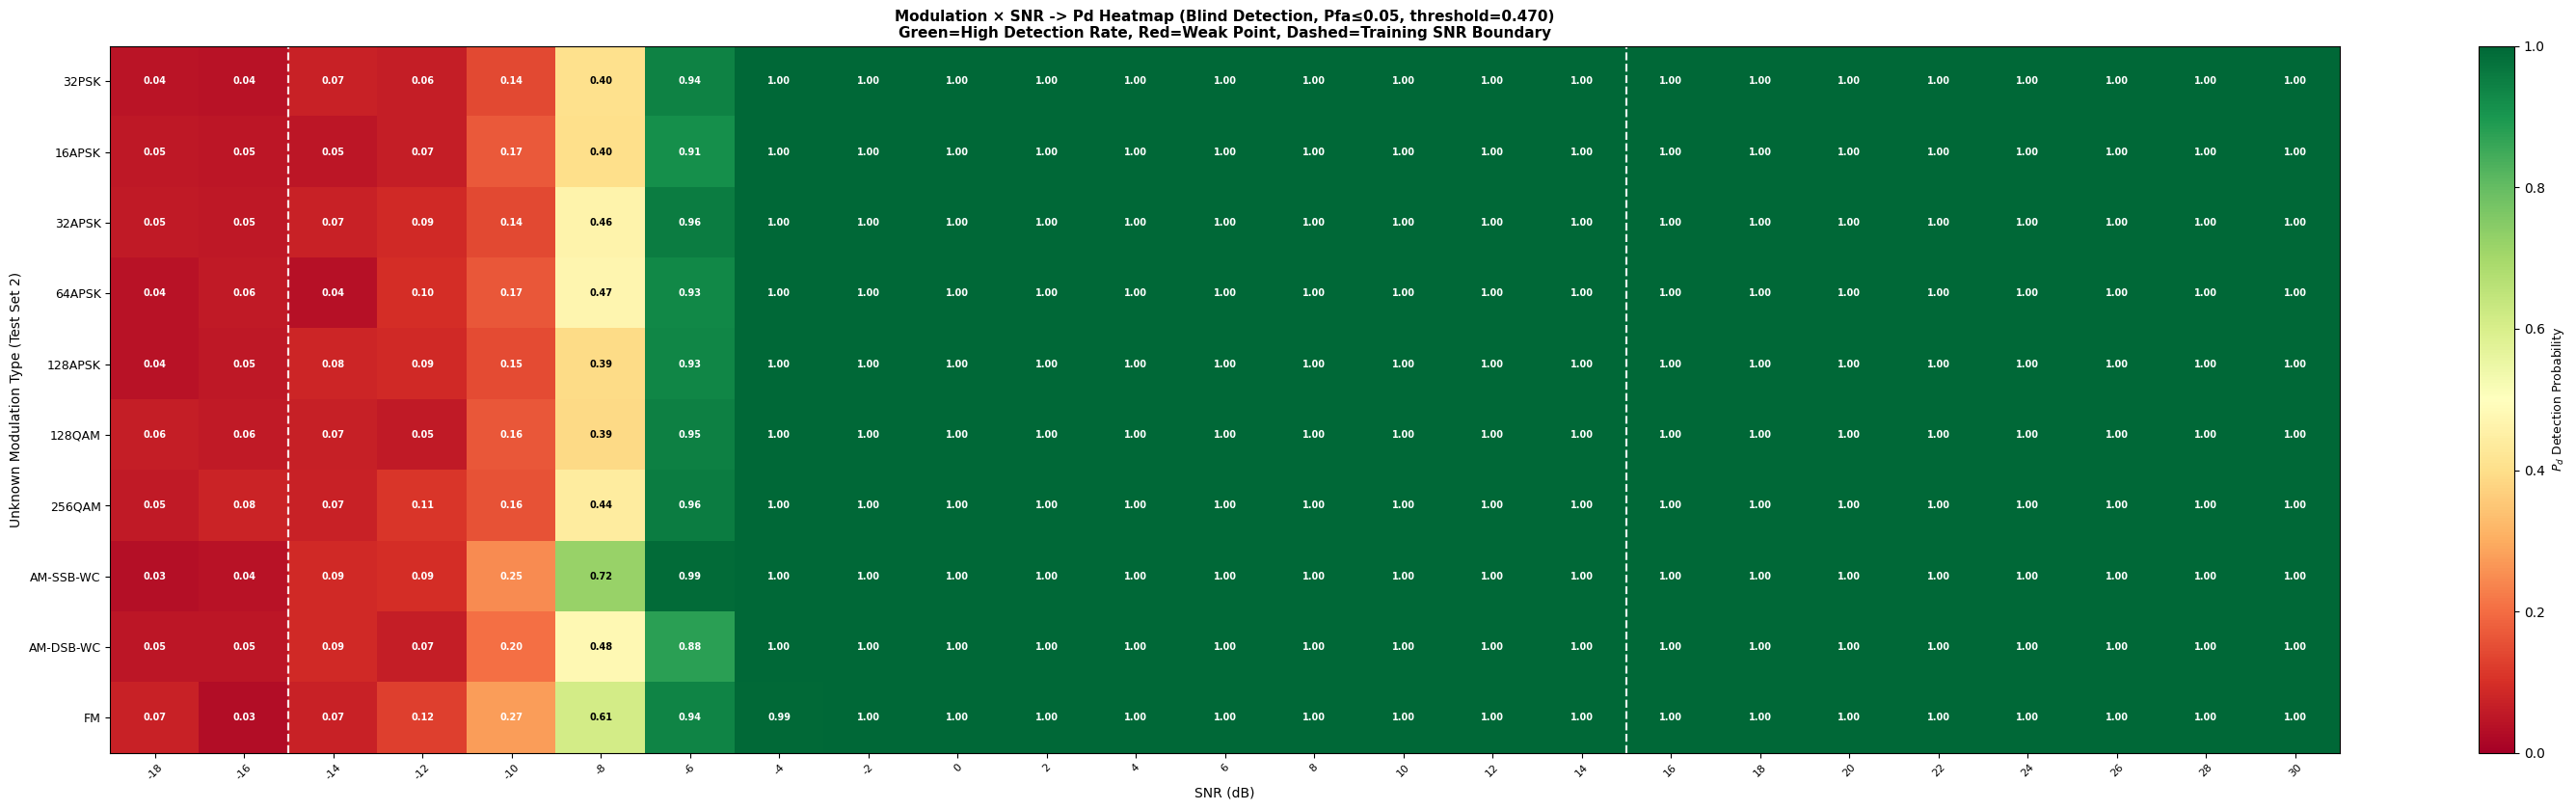

✅ 测试集2盲检测 Modulation × SNR → Pd 热力图绘制完成！
图像已保存到: /kaggle/working/plots/test2_blind_modulation_snr_pd_heatmap.png

📌 Test Set 2 Blind Detection: Overall Pd by SNR
--------------------------------------------------
 SNR(dB) |  Samples |       Pd
--------------------------------------------------
     -18 |     3840 |    4.97%
     -16 |     3840 |    5.00%
     -14 |     3840 |    6.95%
     -12 |     3840 |    8.52%
     -10 |     3840 |   18.12%
      -8 |     3840 |   47.63%
      -6 |     3840 |   93.88%
      -4 |     3840 |   99.90%
      -2 |     3840 |  100.00%
       0 |     3840 |  100.00%
       2 |     3840 |  100.00%
       4 |     3840 |  100.00%
       6 |     3840 |  100.00%
       8 |     3840 |  100.00%
      10 |     3840 |  100.00%
      12 |     3840 |  100.00%
      14 |     3840 |  100.00%
      16 |     3840 |  100.00%
      18 |     3840 |  100.00%
      20 |     3840 |  100.00%
      22 |     3840 |  100.00%
      24 |     3840 |  100.00%
      26 |     3840 |  

In [33]:
# ============================================================
# Cell 11.5: 绘制调制类型 × SNR → Pd 热力图（测试集2，盲检测）
# ============================================================

PLOT_DIR = '/kaggle/working/plots'
os.makedirs(PLOT_DIR, exist_ok=True)


# ============================================================
# 1. 取测试集2中的 H1 样本
# ============================================================
# test2_ds 的构造顺序是：
# [t2_h1_pos, t2_h0d_pos] + awgn_t2
# 所以 test2_probs_h1 的前 len(t2_h1_pos) 个就是测试集2的 H1 样本

n_t2_h1 = len(t2_h1_pos)

probs_t2_h1 = np.asarray(test2_probs_h1[:n_t2_h1])
snrs_t2_h1  = np.asarray(snr_t2_h1)
mods_t2_h1  = np.asarray(mod_t2_h1)

# 按最终阈值进行 H0/H1 判决
preds_t2_h1 = (probs_t2_h1 >= FINAL_THRESHOLD).astype(np.int64)

assert len(probs_t2_h1) == len(snrs_t2_h1) == len(mods_t2_h1), \
    '长度不一致：请检查 test2_probs_h1、snr_t2_h1、mod_t2_h1 是否对应。'


# ============================================================
# 2. 构建 Unknown Modulation × SNR 的 Pd 矩阵
# ============================================================

# 行：未知调制类型
heatmap_mod_names = list(UNKNOWN_MODS)
heatmap_mod_ids = [MOD_CLASSES.index(m) for m in heatmap_mod_names]

# 列：SNR
# 这里不用固定写死，直接从测试集2真实出现的 SNR 中提取
heatmap_snrs = sorted(np.unique(snrs_t2_h1).astype(int).tolist())

pd_matrix = np.full(
    (len(heatmap_mod_ids), len(heatmap_snrs)),
    np.nan,
    dtype=np.float32
)

count_matrix = np.zeros(
    (len(heatmap_mod_ids), len(heatmap_snrs)),
    dtype=np.int64
)

for i, mod_id in enumerate(heatmap_mod_ids):
    for j, snr_db in enumerate(heatmap_snrs):

        mask = (mods_t2_h1 == mod_id) & (snrs_t2_h1 == snr_db)

        count_matrix[i, j] = mask.sum()

        if mask.sum() > 0:
            # 这里全部是真实 H1 样本
            # 所以预测为 H1 的比例就是 Pd
            pd_matrix[i, j] = preds_t2_h1[mask].mean()


# ============================================================
# 3. 绘制热力图
# ============================================================

fig, ax = plt.subplots(
    figsize=(1.05 * len(heatmap_snrs) + 4, 0.55 * len(heatmap_mod_names) + 3)
)

pd_show = np.ma.masked_invalid(pd_matrix)

im = ax.imshow(
    pd_show,
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    aspect='auto'
)

# 坐标轴
ax.set_xticks(np.arange(len(heatmap_snrs)))
ax.set_yticks(np.arange(len(heatmap_mod_names)))

ax.set_xticklabels(heatmap_snrs, rotation=45, fontsize=8)
ax.set_yticklabels(heatmap_mod_names, fontsize=9)

ax.set_xlabel('SNR (dB)', fontsize=10)
ax.set_ylabel('Unknown Modulation Type (Test Set 2)', fontsize=10)

ax.set_title(
    f'Modulation × SNR -> Pd Heatmap '
    f'(Blind Detection, Pfa≤0.05, threshold={FINAL_THRESHOLD:.3f})\n'
    f'Green=High Detection Rate, Red=Weak Point, Dashed=Training SNR Boundary',
    fontsize=11,
    fontweight='bold'
)


# ============================================================
# 4. 添加训练 SNR 边界虚线
# ============================================================
# 作用：标出训练时见过的 SNR 范围，方便观察泛化能力

train_snr_min = min(TRAIN_H1_SNRS)
train_snr_max = max(TRAIN_H1_SNRS)

if train_snr_min in heatmap_snrs:
    left_idx = heatmap_snrs.index(train_snr_min)
    ax.axvline(
        left_idx - 0.5,
        color='white',
        linestyle='--',
        linewidth=1.6,
        alpha=0.9
    )

if train_snr_max in heatmap_snrs:
    right_idx = heatmap_snrs.index(train_snr_max)
    ax.axvline(
        right_idx + 0.5,
        color='white',
        linestyle='--',
        linewidth=1.6,
        alpha=0.9
    )


# ============================================================
# 5. 每个格子标注 Pd 数值
# ============================================================

for i in range(len(heatmap_mod_names)):
    for j in range(len(heatmap_snrs)):

        value = pd_matrix[i, j]

        if np.isnan(value):
            text = 'N/A'
            text_color = 'black'
        else:
            text = f'{value:.2f}'

            # 深色背景用白字，浅色背景用黑字
            if value < 0.35 or value > 0.75:
                text_color = 'white'
            else:
                text_color = 'black'

        ax.text(
            j,
            i,
            text,
            ha='center',
            va='center',
            fontsize=7,
            fontweight='bold',
            color=text_color
        )


# ============================================================
# 6. 颜色条
# ============================================================

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$P_d$ Detection Probability', fontsize=9)

plt.tight_layout()

save_path = f'{PLOT_DIR}/test2_blind_modulation_snr_pd_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print('✅ 测试集2盲检测 Modulation × SNR → Pd 热力图绘制完成！')
print(f'图像已保存到: {save_path}')


# ============================================================
# 7. 输出每个 SNR 下的整体 Pd，方便写论文或汇报
# ============================================================

print('\n📌 Test Set 2 Blind Detection: Overall Pd by SNR')
print('-' * 50)
print(f'{"SNR(dB)":>8} | {"Samples":>8} | {"Pd":>8}')
print('-' * 50)

for snr_db in heatmap_snrs:
    mask = (snrs_t2_h1 == snr_db)
    n = mask.sum()

    if n > 0:
        pd_snr = preds_t2_h1[mask].mean()
        print(f'{snr_db:>8} | {n:>8} | {pd_snr:>8.2%}')
    else:
        print(f'{snr_db:>8} | {0:>8} | {"N/A":>8}')

print('-' * 50)

---
## Cell 12｜科研级综合可视化

### 📖 五大图表说明

| 图表 | 科研价值 |
|---|---|
| ①归一化混淆矩阵 | 直观展示 Pd / Pfa，定位漏检与虚警 |
| ②ROC 曲线 | 评估检测器在所有判决阈值下的综合性能（AUC） |
| ③Pd-SNR 曲线 | 频谱感知的"灵魂曲线"，揭示低SNR灵敏度 |
| ④**调制×SNR 热力图** | 盲检测专项分析，定位模型对哪些调制/SNR组合最弱 |
| ⑤概率分布图 | 直观展示 H0/H1 的可分性（双峰分离程度） |

### 🌡️ 调制×SNR 热力图的科研意义

$$P_d(m, s) = P(\hat{y}=H_1 \mid y=H_1,\; \text{mod}=m,\; \text{SNR}=s)$$

颜色越绿表示该调制在该SNR下检测概率越高；颜色越红表示容易漏检。
这是论文中最有说服力的图之一：**清晰定位模型的弱点**，为后续改进提供方向。

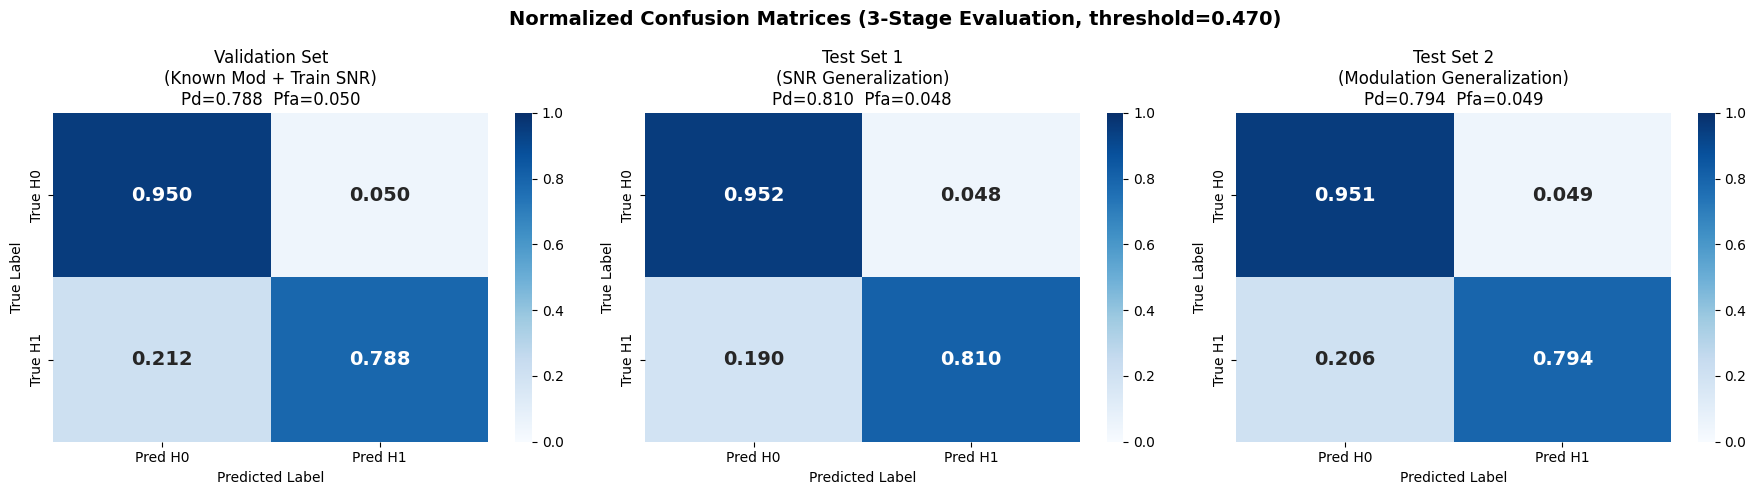

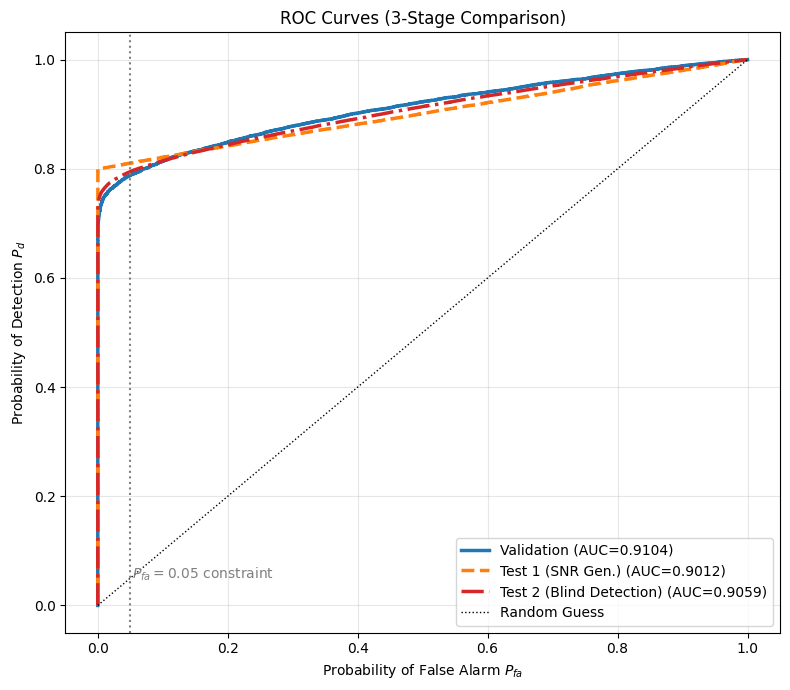

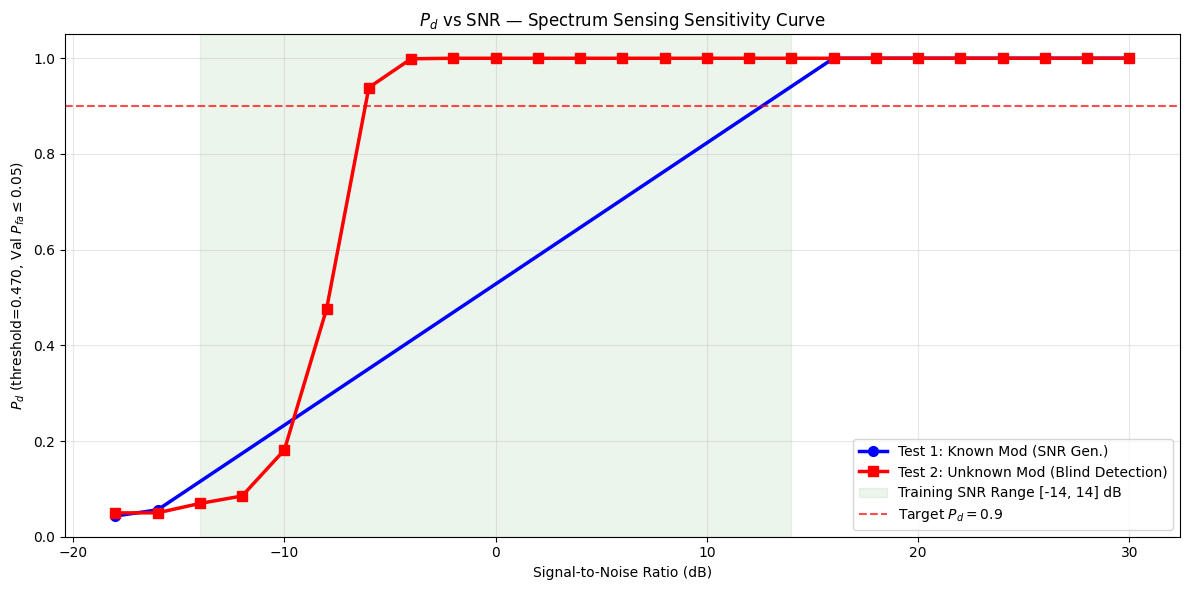


🌡️ 绘制调制类型 × SNR → Pd 热力图（测试集2，盲检测）...


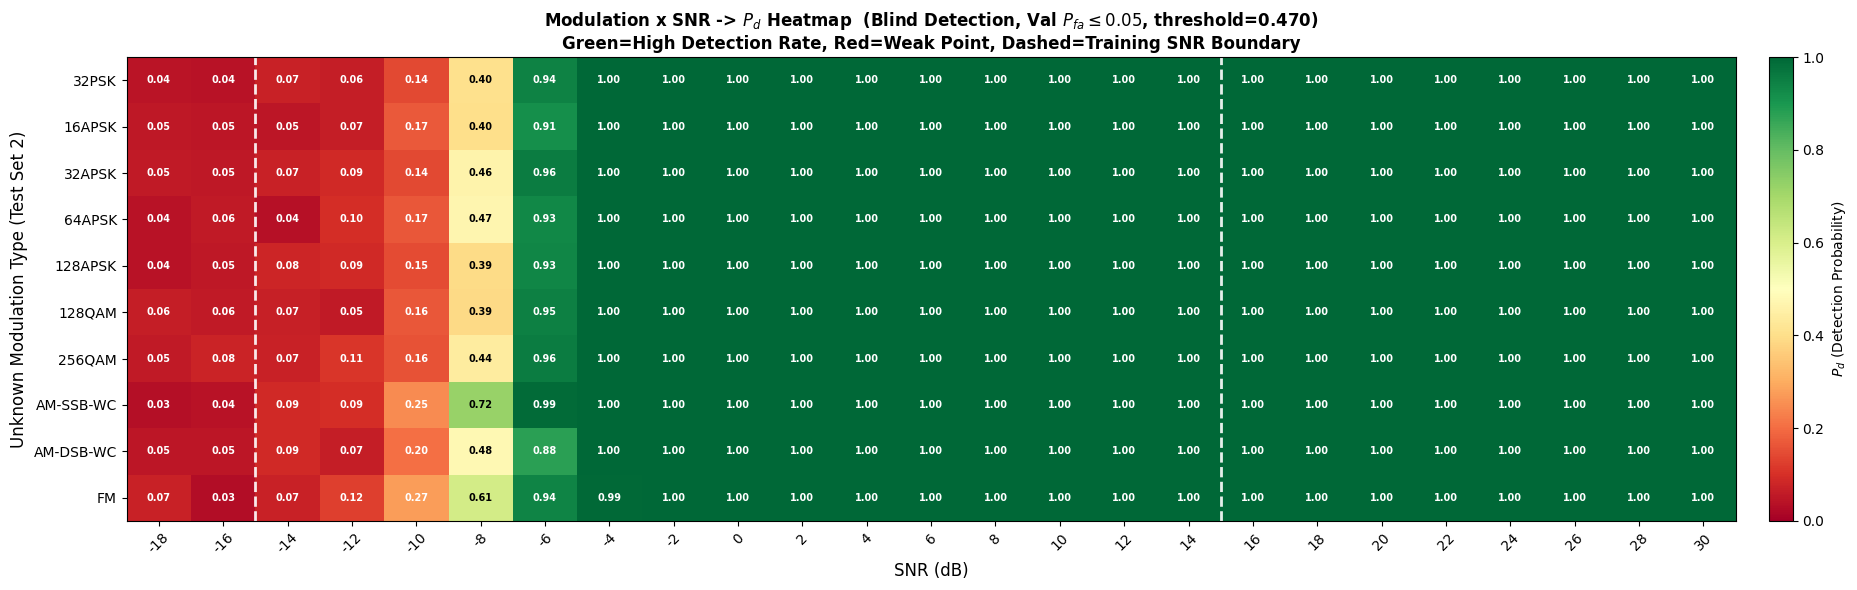

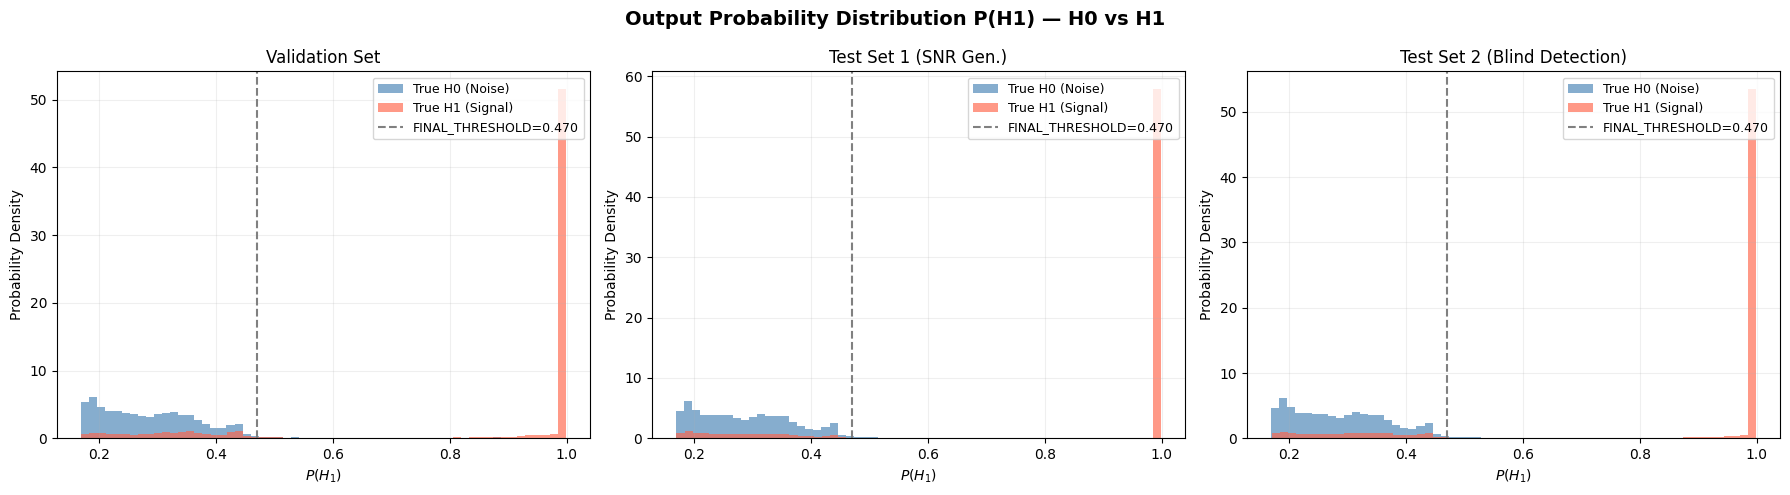


💡 双峰分离越明显→模型判别力越强；中间重叠区域是“模糊地带”（误判来源）。
✅ Cell 12 Comprehensive Visualization 完成！
图像已保存到: /kaggle/working/plots


In [ ]:
# ============================================================
# Cell 12: Comprehensive Visualization
# 颜色风格与参考代码保持一致：
# Confusion Matrix: Blues
# ROC: blue / orange / red
# Pd-SNR: blue circles / red squares
# Heatmap: RdYlGn
# Probability Distribution: steelblue / tomato
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

PLOT_DIR = '/kaggle/working/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

# 统一实验口径：阈值来自验证集 Pfa≤5% 下 Pd 最优搜索
TARGET_PFA = 0.05

# 为了兼容你参考代码中的变量命名
true_v  = val_labels
true_t1 = test1_labels
true_t2 = test2_labels

prob_v  = np.column_stack([1 - val_probs_h1,   val_probs_h1])
prob_t1 = np.column_stack([1 - test1_probs_h1, test1_probs_h1])
prob_t2 = np.column_stack([1 - test2_probs_h1, test2_probs_h1])


# ============================================================
# ① Normalized Confusion Matrix
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Normalized Confusion Matrices (3-Stage Evaluation, threshold={FINAL_THRESHOLD:.3f})',
    fontsize=14,
    fontweight='bold'
)

for ax, (m, title) in zip(axes, [
    (m_v,  'Validation Set\n(Known Mod + Train SNR)'),
    (m_t1, 'Test Set 1\n(SNR Generalization)'),
    (m_t2, 'Test Set 2\n(Modulation Generalization)')
]):
    cm_n = m['cm'].astype(float) / (m['cm'].sum(axis=1, keepdims=True) + 1e-12)

    sns.heatmap(
        cm_n,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        ax=ax,
        xticklabels=['Pred H0', 'Pred H1'],
        yticklabels=['True H0', 'True H1'],
        vmin=0,
        vmax=1,
        annot_kws={'size': 14, 'weight': 'bold'}
    )

    ax.set_title(f'{title}\nPd={m["Pd"]:.3f}  Pfa={m["Pfa"]:.3f}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_normalized_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ② ROC Curves
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for (m, lbl), ls, c in zip(
    [
        (m_v,  'Validation'),
        (m_t1, 'Test 1 (SNR Gen.)'),
        (m_t2, 'Test 2 (Blind Detection)')
    ],
    ['-', '--', '-.'],
    ['#1f77b4', '#ff7f0e', '#d62728']
):
    ax.plot(
        m['fpr'],
        m['tpr'],
        ls=ls,
        color=c,
        lw=2.5,
        label=f'{lbl} (AUC={m["auc"]:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random Guess')
ax.axvline(TARGET_PFA, color='gray', ls=':', lw=1.5)
ax.text(
    TARGET_PFA + 0.002,
    0.05,
    f'$P_{{fa}}={TARGET_PFA:.2f}$ constraint',
    color='gray',
    fontsize=10
)

ax.set_xlabel('Probability of False Alarm $P_{fa}$')
ax.set_ylabel('Probability of Detection $P_d$')
ax.set_title('ROC Curves (3-Stage Comparison)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ③ Pd vs SNR Curve
# ============================================================

def calc_pd_snr(labels, probs_h1, snrs_h1, threshold):
    """
    按 SNR 统计 H1 样本的检测概率 Pd。
    注意：
        snrs_h1 只对应 H1 样本，因此需要先从 probs_h1 中取 labels==1 的部分。
    """
    labels = np.asarray(labels)
    probs_h1 = np.asarray(probs_h1)
    snrs_h1 = np.asarray(snrs_h1)

    h1_probs = probs_h1[labels == 1]

    assert len(h1_probs) == len(snrs_h1), \
        f'H1概率数量({len(h1_probs)}) 与 SNR数量({len(snrs_h1)}) 不一致，请检查 DataLoader 是否 shuffle=False。'

    pd_by_snr = {}

    for snr_db in sorted(np.unique(snrs_h1).astype(int).tolist()):
        mask = (snrs_h1 == snr_db)
        if mask.sum() > 0:
            pd_by_snr[snr_db] = (h1_probs[mask] >= threshold).mean()

    return pd_by_snr


pd_snr_t1 = calc_pd_snr(true_t1, prob_t1[:, 1], snr_t1_h1, FINAL_THRESHOLD)
pd_snr_t2 = calc_pd_snr(true_t2, prob_t2[:, 1], snr_t2_h1, FINAL_THRESHOLD)

fig, ax = plt.subplots(figsize=(12, 6))

s1, p1 = zip(*sorted(pd_snr_t1.items()))
s2, p2 = zip(*sorted(pd_snr_t2.items()))

ax.plot(
    s1,
    p1,
    'b-o',
    lw=2.5,
    ms=7,
    label='Test 1: Known Mod (SNR Gen.)'
)

ax.plot(
    s2,
    p2,
    'r-s',
    lw=2.5,
    ms=7,
    label='Test 2: Unknown Mod (Blind Detection)'
)

ax.axvspan(
    TRAIN_H1_SNRS[0],
    TRAIN_H1_SNRS[-1],
    alpha=0.08,
    color='green',
    label=f'Training SNR Range [{TRAIN_H1_SNRS[0]}, {TRAIN_H1_SNRS[-1]}] dB'
)

ax.axhline(
    0.9,
    color='red',
    ls='--',
    alpha=0.7,
    lw=1.5,
    label='Target $P_d=0.9$'
)

ax.set_xlabel('Signal-to-Noise Ratio (dB)')
ax.set_ylabel(f'$P_d$ (threshold={FINAL_THRESHOLD:.3f}, Val $P_{{fa}}\\leq{TARGET_PFA:.2f}$)')
ax.set_title('$P_d$ vs SNR — Spectrum Sensing Sensitivity Curve')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_pd_vs_snr_curve.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ④ Modulation × SNR Heatmap
# ============================================================

print('\n🌡️ 绘制调制类型 × SNR → Pd 热力图（测试集2，盲检测）...')

# 重要：不在测试集2上重新选阈值，统一使用验证集确定的 FINAL_THRESHOLD
best_th = FINAL_THRESHOLD

snr_uniq  = sorted(np.unique(snr_t2_h1).astype(int).tolist())
mod_uniq  = sorted(np.unique(mod_t2_h1).astype(int).tolist())
mod_names = [MOD_CLASSES[i] for i in mod_uniq]

# 只提取测试集2真实 H1 样本的 H1 概率，确保与 snr_t2_h1 / mod_t2_h1 等长
h1_prob = prob_t2[true_t2 == 1, 1]

assert len(h1_prob) == len(snr_t2_h1) == len(mod_t2_h1), \
    '测试集2 H1概率、SNR、调制标签长度不一致，请检查 test2_loader 是否 shuffle=False。'

hm = np.full((len(mod_uniq), len(snr_uniq)), np.nan)

for i, mid in enumerate(mod_uniq):
    for j, s in enumerate(snr_uniq):
        mask = (snr_t2_h1 == s) & (mod_t2_h1 == mid)
        if mask.sum() > 0:
            hm[i, j] = (h1_prob[mask] >= best_th).mean()

fig_h = max(6, len(mod_uniq) * 0.55)
fig_w = max(14, len(snr_uniq) * 0.75)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(
    hm,
    cmap='RdYlGn',
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(
    im,
    ax=ax,
    label='$P_d$ (Detection Probability)',
    fraction=0.03,
    pad=0.02
)

ax.set_xticks(range(len(snr_uniq)))
ax.set_xticklabels([str(s) for s in snr_uniq], rotation=45)
ax.set_yticks(range(len(mod_uniq)))
ax.set_yticklabels(mod_names)

for i in range(len(mod_uniq)):
    for j in range(len(snr_uniq)):
        if not np.isnan(hm[i, j]):
            v = hm[i, j]
            fc = 'white' if (v < 0.35 or v > 0.85) else 'black'
            ax.text(
                j,
                i,
                f'{v:.2f}',
                ha='center',
                va='center',
                fontsize=7,
                color=fc,
                fontweight='bold'
            )

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Unknown Modulation Type (Test Set 2)', fontsize=12)

ax.set_title(
    f'Modulation x SNR -> $P_d$ Heatmap  (Blind Detection, '
    f'Val $P_{{fa}}\\leq{TARGET_PFA:.2f}$, threshold={best_th:.3f})\n'
    f'Green=High Detection Rate, Red=Weak Point, Dashed=Training SNR Boundary',
    fontsize=12,
    fontweight='bold'
)

# 训练SNR边界虚线
for s_val, offset in [
    (TRAIN_H1_SNRS[0], -0.5),
    (TRAIN_H1_SNRS[-1], 0.5)
]:
    if s_val in snr_uniq:
        j_line = snr_uniq.index(s_val)
        ax.axvline(
            j_line + offset,
            color='white',
            lw=2,
            ls='--',
            alpha=0.9
        )

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_modulation_snr_pd_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# ⑤ Output Probability Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Output Probability Distribution P(H1) — H0 vs H1',
    fontsize=14,
    fontweight='bold'
)

for ax, (yt, ph1, title) in zip(axes, [
    (true_v,  prob_v[:, 1],  'Validation Set'),
    (true_t1, prob_t1[:, 1], 'Test Set 1 (SNR Gen.)'),
    (true_t2, prob_t2[:, 1], 'Test Set 2 (Blind Detection)')
]):
    ax.hist(
        ph1[yt == 0],
        bins=60,
        alpha=0.65,
        color='steelblue',
        label='True H0 (Noise)',
        density=True
    )

    ax.hist(
        ph1[yt == 1],
        bins=60,
        alpha=0.65,
        color='tomato',
        label='True H1 (Signal)',
        density=True
    )

    ax.axvline(
        FINAL_THRESHOLD,
        color='gray',
        ls='--',
        lw=1.5,
        label=f'FINAL_THRESHOLD={FINAL_THRESHOLD:.3f}'
    )

    ax.set_title(title)
    ax.set_xlabel('$P(H_1)$')
    ax.set_ylabel('Probability Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n💡 双峰分离越明显→模型判别力越强；中间重叠区域是“模糊地带”（误判来源）。')
print('✅ Cell 12 Comprehensive Visualization 完成！')
print(f'图像已保存到: {PLOT_DIR}')


---
## Cell 13｜保存模型与实验报告

### 📖 保存内容清单

| 文件 | 内容 | 用途 |
|---|---|---|
| `best_dual_branch.pth` | 最优验证损失对应的模型权重 | 后续推理、继续训练 |
| `metrics_summary.json` | 三阶段评估指标汇总 | 实验记录、论文数据 |

### 📝 实验可复现要素

论文的可复现性需要同时记录：随机种子、模型超参、数据划分策略、训练设置。
这些信息均保存在 `metrics_summary.json` 中，便于他人复现。

In [ ]:
# ============================================================
# Cell 13: 保存模型与实验结果
# ============================================================

import os
import json
import time
import pandas as pd
import torch

SAVE_DIR = '/kaggle/working/final_results'
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = time.strftime('%Y%m%d_%H%M%S')


# ============================================================
# 1. 安全转换 metrics 字典
# ============================================================
# m_v / m_t1 / m_t2 里面有 cm、preds 这类数组，不能直接 float()
# 所以这里只保存标量指标。
# ============================================================

def clean_metrics_dict(m):
    """
    只保留可以保存成 JSON 的标量指标。
    """
    keep_keys = [
        'threshold',
        'acc',
        'f1',
        'Pd',
        'Pfa',
        'AUC'
    ]

    clean = {}

    for k in keep_keys:
        if k in m:
            clean[k] = float(m[k])

    return clean


results = {
    'experiment_time': timestamp,
    'model_name': 'DualBranchSpectrumNet (BiLSTM + SE-8modal-ResNet18 + BCA + LowSNR Sampling + Threshold Optimization)',
    'final_threshold': float(FINAL_THRESHOLD),

    'dataset_setting': {
        'train_snr': [int(x) for x in TRAIN_H1_SNRS],
        'test1_snr': [int(x) for x in TEST1_H1_SNRS],
        'test2_snr': [int(x) for x in TEST2_H1_SNRS],
        'h0_snr': int(H0_SNR)
    },

    'metrics': {
        'Validation': clean_metrics_dict(m_v),
        'Test1_SNR_Generalization': clean_metrics_dict(m_t1),
        'Test2_Modulation_Generalization': clean_metrics_dict(m_t2)
    }
}


# ============================================================
# 2. 保存 JSON 结果
# ============================================================

json_path = f'{SAVE_DIR}/experiment_results_{timestamp}.json'

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

print(f'✅ 实验结果 JSON 已保存: {json_path}')


# ============================================================
# 3. 保存 CSV 结果表
# ============================================================

summary_rows = []

for name, m in [
    ('Validation', m_v),
    ('Test1_SNR_Generalization', m_t1),
    ('Test2_Modulation_Generalization', m_t2)
]:
    summary_rows.append({
        'Dataset': name,
        'Threshold': float(FINAL_THRESHOLD),
        'Accuracy': float(m['acc']),
        'Pd': float(m['Pd']),
        'Pfa': float(m['Pfa']),
        'AUC': float(m['AUC']),
        'F1': float(m['f1'])
    })

summary_df = pd.DataFrame(summary_rows)

csv_path = f'{SAVE_DIR}/experiment_summary_{timestamp}.csv'
summary_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f'✅ 实验结果 CSV 已保存: {csv_path}')


# ============================================================
# 4. 保存模型权重
# ============================================================

model_path = f'{SAVE_DIR}/best_model_{timestamp}.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'final_threshold': float(FINAL_THRESHOLD),
    'results': results,
    'history': history
}, model_path)

print(f'✅ 最优模型已保存: {model_path}')


# ============================================================
# 5. 保存训练曲线数据
# ============================================================

history_df = pd.DataFrame({
    'epoch': list(range(1, len(history['tr_loss']) + 1)),
    'train_loss': history['tr_loss'],
    'val_loss': history['val_loss'],
    'train_acc': history['tr_acc'],
    'val_acc': history['val_acc']
})

history_path = f'{SAVE_DIR}/training_history_{timestamp}.csv'
history_df.to_csv(history_path, index=False, encoding='utf-8-sig')

print(f'✅ 训练历史已保存: {history_path}')


# ============================================================
# 6. 打印最终汇总表
# ============================================================

print('\n' + '=' * 90)
print('📌 最终实验结果汇总')
print('=' * 90)
print('模型：BiLSTM + SE-8模态 ResNet18 + BCA + 低SNR过采样 + 阈值优化')
print(f'最终阈值 FINAL_THRESHOLD = {FINAL_THRESHOLD:.3f}')
print('-' * 90)
print(f'{"数据集":<32} | {"Acc":>8} | {"Pd":>8} | {"Pfa":>8} | {"AUC":>8} | {"F1":>8}')
print('-' * 90)

for name, m in [
    ('Validation', m_v),
    ('Test1_SNR_Generalization', m_t1),
    ('Test2_Modulation_Generalization', m_t2)
]:
    print(
        f'{name:<32} | '
        f'{m["acc"]:>8.2%} | '
        f'{m["Pd"]:>8.2%} | '
        f'{m["Pfa"]:>8.2%} | '
        f'{m["AUC"]:>8.4f} | '
        f'{m["f1"]:>8.4f}'
    )

print('=' * 90)

print('\n✅ Cell 13 保存完成！')
print(f'结果文件目录: {SAVE_DIR}')

✅ 实验结果 JSON 已保存: /kaggle/working/final_results/experiment_results_20260605_100507.json
✅ 实验结果 CSV 已保存: /kaggle/working/final_results/experiment_summary_20260605_100507.csv
✅ 最优模型已保存: /kaggle/working/final_results/best_model_20260605_100507.pth
✅ 训练历史已保存: /kaggle/working/final_results/training_history_20260605_100507.csv

📌 最终实验结果汇总
模型：BiLSTM + SE-8模态 ResNet18 + BCA + 低SNR过采样 + 阈值优化
最终阈值 FINAL_THRESHOLD = 0.470
------------------------------------------------------------------------------------------
数据集                              |      Acc |       Pd |      Pfa |      AUC |       F1
------------------------------------------------------------------------------------------
Validation                       |   86.91% |   78.81% |    5.00% |   0.9104 |   0.8575
Test1_SNR_Generalization         |   88.07% |   81.00% |    4.85% |   0.9012 |   0.8717
Test2_Modulation_Generalization  |   87.27% |   79.40% |    4.86% |   0.9059 |   0.8618

✅ Cell 13 保存完成！
结果文件目录: /kaggle/working/final_resul